In [24]:
from helpers import *
import numpy as np
from pandas import DataFrame, concat
import pandas as pd
from IPython.display import display, Markdown

In [40]:
# 품질 점검 완료 데이터 셋 가져오기
origin = pd.read_excel("local_data2.xlsx")

In [41]:
origin = origin.drop(columns=["TOP3_업종"])

In [42]:
# 가맹점수_ 로 시작하는 원본 업종별 가맹점수 컬럼 삭제
drop_cols = [
    col for col in origin.columns
    if col.startswith("가맹점수_")
]

origin = origin.drop(columns=drop_cols)

In [43]:
df1 = my_qtcheck.set_type(origin, as_category=[])

<class 'pandas.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 23 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   행정동코드        260 non-null    int64  
 1   행정구역         260 non-null    str    
 2   총인구수         260 non-null    float64
 3   월유동인구수       260 non-null    float64
 4   전체가맹점수       260 non-null    float64
 5   소매_비율        260 non-null    float64
 6   숙박_비율        260 non-null    float64
 7   음식_비율        260 non-null    float64
 8   부동산_비율       260 non-null    float64
 9   과학·기술_비율     260 non-null    float64
 10  시설관리·임대_비율   260 non-null    float64
 11  교육_비율        260 non-null    float64
 12  보건의료_비율      260 non-null    float64
 13  예술·스포츠_비율    260 non-null    float64
 14  수리·개인_비율     260 non-null    float64
 15  기타_비율        260 non-null    float64
 16  1인당_유동인구     260 non-null    float64
 17  평균매출         260 non-null    float64
 18  총_가맹점수       260 non-null    float64
 19  만명당_가맹점수     260 no

In [44]:
# 중복값 제거
df2 = my_qtcheck.check_duplicates(df1)
df2.head()

중복된 행의 수: 0


,행정동코드,행정구역,총인구수,월유동인구수,전체가맹점수,소매_비율,숙박_비율,음식_비율,부동산_비율,과학·기술_비율,...,예술·스포츠_비율,수리·개인_비율,기타_비율,1인당_유동인구,평균매출,총_가맹점수,만명당_가맹점수,위도,경도,서울중심지_거리_km
0,4111156000,경기도 수원시 장안구 파장동,24479.416667,2.465431e+05,697.666667,0.377449,0.003344,0.341137,0.001433,0.009556,...,0.032489,0.128046,0.028667,10.071444,2.309790e+06,697.666667,285.001345,37.320531,126.989378,27.378798
1,4111156600,경기도 수원시 장안구 율천동,40142.208333,5.287070e+05,1109.333333,0.216046,0.002404,0.402644,0.002404,0.007212,...,0.061899,0.145132,0.028245,13.170850,6.843445e+06,1109.333333,276.350848,37.299592,126.971753,29.695822
2,4111157100,경기도 수원시 장안구 정자1동,31046.958333,3.570282e+05,432.666667,0.291217,0.004622,0.270416,0.000000,0.007704,...,0.035439,0.131741,0.030046,11.499619,4.337255e+06,432.666667,139.358794,37.304703,126.989323,29.137576
3,4111157200,경기도 수원시 장안구 정자2동,37978.750000,1.329960e+06,746.000000,0.338695,0.006256,0.315460,0.001340,0.006702,...,0.029044,0.172922,0.030831,35.018519,4.340631e+06,746.000000,196.425633,37.292271,126.998383,30.555018
4,4111157300,경기도 수원시 장안구 정자3동,39261.500000,6.991828e+05,1044.666667,0.238992,0.000000,0.291002,0.001595,0.010530,...,0.051053,0.118698,0.018826,17.808357,1.385744e+07,1044.666667,266.079153,37.298399,126.984661,29.827806


In [45]:
# 결측치 비율 확인
my_qtcheck.check_missing_values(df2)

,Missing Count,Missing Ratio (%)
행정동코드,0,0.0
행정구역,0,0.0
총인구수,0,0.0
월유동인구수,0,0.0
전체가맹점수,0,0.0
소매_비율,0,0.0
숙박_비율,0,0.0
음식_비율,0,0.0
부동산_비율,0,0.0
과학·기술_비율,0,0.0


In [46]:

df2_numerical_qtcheck = my_qtcheck.numerical_summary(df2, save_path=None)

In [47]:
display(df2)
display(df2_numerical_qtcheck.T)

,행정동코드,행정구역,총인구수,월유동인구수,전체가맹점수,소매_비율,숙박_비율,음식_비율,부동산_비율,과학·기술_비율,...,예술·스포츠_비율,수리·개인_비율,기타_비율,1인당_유동인구,평균매출,총_가맹점수,만명당_가맹점수,위도,경도,서울중심지_거리_km
0,4111156000,경기도 수원시 장안구 파장동,24479.416667,2.465431e+05,697.666667,0.377449,0.003344,0.341137,0.001433,0.009556,...,0.032489,0.128046,0.028667,10.071444,2.309790e+06,697.666667,285.001345,37.320531,126.989378,27.378798
1,4111156600,경기도 수원시 장안구 율천동,40142.208333,5.287070e+05,1109.333333,0.216046,0.002404,0.402644,0.002404,0.007212,...,0.061899,0.145132,0.028245,13.170850,6.843445e+06,1109.333333,276.350848,37.299592,126.971753,29.695822
2,4111157100,경기도 수원시 장안구 정자1동,31046.958333,3.570282e+05,432.666667,0.291217,0.004622,0.270416,0.000000,0.007704,...,0.035439,0.131741,0.030046,11.499619,4.337255e+06,432.666667,139.358794,37.304703,126.989323,29.137576
3,4111157200,경기도 수원시 장안구 정자2동,37978.750000,1.329960e+06,746.000000,0.338695,0.006256,0.315460,0.001340,0.006702,...,0.029044,0.172922,0.030831,35.018519,4.340631e+06,746.000000,196.425633,37.292271,126.998383,30.555018
4,4111157300,경기도 수원시 장안구 정자3동,39261.500000,6.991828e+05,1044.666667,0.238992,0.000000,0.291002,0.001595,0.010530,...,0.051053,0.118698,0.018826,17.808357,1.385744e+07,1044.666667,266.079153,37.298399,126.984661,29.827806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,4165051000,경기도 포천시 포천동,19244.625000,2.745048e+04,997.333333,0.291444,0.011029,0.400735,0.001003,0.013703,...,0.033757,0.140040,0.032420,1.426397,4.163315e+06,997.333333,518.239941,37.894277,127.182004,40.598005
256,4165052000,경기도 포천시 선단동,14205.875000,4.111333e+04,483.000000,0.360248,0.001380,0.395445,0.002070,0.006901,...,0.039337,0.132505,0.028986,2.894108,1.184132e+06,483.000000,340.000176,37.861382,127.146841,35.971525
257,4167051000,경기도 여주시 여흥동,20778.000000,3.022585e+04,1117.666667,0.314942,0.010438,0.372502,0.000895,0.016701,...,0.042648,0.121086,0.036684,1.454704,8.919619e+06,1117.666667,537.908685,37.255895,127.650435,68.677784
258,4167052000,경기도 여주시 중앙동,24840.416667,2.464467e+04,1110.666667,0.383854,0.000300,0.314526,0.000000,0.011405,...,0.036615,0.130252,0.033313,0.992120,5.702044e+06,1110.666667,447.120788,37.274453,127.618109,65.167080


,행정동코드,총인구수,월유동인구수,전체가맹점수,소매_비율,숙박_비율,음식_비율,부동산_비율,과학·기술_비율,시설관리·임대_비율,...,예술·스포츠_비율,수리·개인_비율,기타_비율,1인당_유동인구,평균매출,총_가맹점수,만명당_가맹점수,위도,경도,서울중심지_거리_km
count,260.0,260.0,260.0,260.0,260.0,260.0,260.0,260.0,260.0,260.0,...,260.0,260.0,260.0,260.0,260.0,260.0,260.0,260.0,260.0,260.0
mean,4131567895.384615,26059.542468,468258.3433,732.339744,0.297994,0.003756,0.336644,0.001076,0.012022,0.003804,...,0.043321,0.136319,0.028915,21.068004,18829866.649038,732.339744,304.971812,37.413193,127.001981,29.604094
std,15619665.534937,12292.961871,557102.008295,458.936871,0.060206,0.007972,0.066666,0.002125,0.008338,0.002871,...,0.013946,0.026992,0.011282,27.82589,64402971.425538,458.936871,200.230659,0.21244,0.156258,12.837253
min,4111156000.0,1547.625,737.935417,48.666667,0.161889,0.0,0.117562,0.0,0.0,0.0,...,0.0,0.031451,0.005357,0.470876,78043.375,48.666667,35.297246,36.981691,126.58874,9.30956
25%,4117358750.0,17613.572917,102383.758958,413.75,0.252321,0.0,0.291881,0.0,0.007234,0.001843,...,0.033553,0.119228,0.021473,4.129418,2379390.260417,413.75,195.886758,37.274699,126.875415,19.778749
50%,4128157000.0,24441.0,292525.3975,647.833333,0.292161,0.00141,0.344203,0.000535,0.010557,0.003463,...,0.044885,0.139089,0.027595,11.369537,4573823.541667,647.833333,248.731477,37.349577,127.012379,28.935343
75%,4145334250.0,34314.697917,585338.936458,923.583333,0.333016,0.004702,0.376898,0.001532,0.01489,0.005284,...,0.052922,0.154341,0.034528,23.593814,8726342.947917,923.583333,341.624296,37.590738,127.084567,35.326152
max,4167053000.0,68779.125,3165938.191667,2691.333333,0.545416,0.10077,0.504281,0.027397,0.075342,0.017751,...,0.085455,0.1972,0.095299,176.313867,587586181.5,2691.333333,1670.467248,37.947779,127.650435,68.79466
rel_diff,0.000826,0.066222,0.600744,0.130445,0.019963,1.6646,0.021959,1.011761,0.138794,0.098262,...,0.034834,0.019919,0.047831,0.853022,3.116876,0.130445,0.226109,0.001703,0.000082,0.023112
rdiff_flag,similar,similar,large_diff,diff,similar,large_diff,similar,large_diff,diff,similar,...,similar,similar,similar,large_diff,large_diff,diff,diff,similar,similar,similar


In [48]:
df2.to_excel("streeteasy_qtcheck.xlsx", index=False)

df2_numerical_qtcheck.to_excel("streeteasy_numerical_qtcheck.xlsx")

In [49]:
# 4. 변수 유형 분류
# 종속변수
target = "평균매출"
# 종속변수 연속형 여부
target_is_continuous = True

# 명목형 변수
nominal_cols = my_qtcheck.get_categorical_column_names(df2)
# 연속형 변수
continuous_cols = my_qtcheck.get_number_column_names(df2)

if target_is_continuous:
    # 연속형 변수 이름에서 종속변수 항목 제거
    continuous_cols.remove(target)
else:
    # 명목형 변수 이름에서 종속변수 항목 제거
    nominal_cols.remove(target)

print("종속변수 :", target)
print("종속변수 유형: " + ("연속형" if target_is_continuous else "명목형"))
print("명목형 :", nominal_cols)
print("연속형 :", continuous_cols)

종속변수 : 평균매출
종속변수 유형: 연속형
명목형 : []
연속형 : ['행정동코드', '총인구수', '월유동인구수', '전체가맹점수', '소매_비율', '숙박_비율', '음식_비율', '부동산_비율', '과학·기술_비율', '시설관리·임대_비율', '교육_비율', '보건의료_비율', '예술·스포츠_비율', '수리·개인_비율', '기타_비율', '1인당_유동인구', '총_가맹점수', '만명당_가맹점수', '위도', '경도', '서울중심지_거리_km']


In [50]:
# 품질 점검 완료 데이터 셋 가져오기
origin = pd.read_excel("streeteasy_qtcheck.xlsx")
num_desc = pd.read_excel("streeteasy_numerical_qtcheck.xlsx", index_col=0)

In [51]:
column_means = {
    "행정동코드": "행정동 코드",
    "행정구역": "행정구역명",
    "총인구수": "총 인구수",
    "월유동인구수": "월 유동인구수",
    "전체가맹점수": "전체 가맹점 수",

    "소매_비율": "소매업 가맹점 비율",
    "숙박_비율": "숙박업 가맹점 비율",
    "음식_비율": "음식업 가맹점 비율",
    "부동산_비율": "부동산업 가맹점 비율",
    "과학·기술_비율": "과학·기술업 가맹점 비율",
    "시설관리·임대_비율": "시설관리·임대업 가맹점 비율",
    "교육_비율": "교육업 가맹점 비율",
    "보건의료_비율": "보건의료업 가맹점 비율",
    "예술·스포츠_비율": "예술·스포츠업 가맹점 비율",
    "수리·개인_비율": "수리·개인서비스업 가맹점 비율",
    "기타_비율": "기타업종 가맹점 비율",

    "1인당_유동인구": "1인당 유동인구",
    "평균매출": "평균 지역화폐 매출",
    "총_가맹점수": "총 가맹점 수",
    "만명당_가맹점수": "인구 1만 명당 가맹점 수",

    "위도": "위도",
    "경도": "경도",
    "서울중심지_거리_km": "서울 중심지까지 거리(km)"
}

In [52]:
# 종속변수 기술통계량 추출
num_desc.loc[[target]].T

,평균매출
count,260
mean,18829866.649038
std,64402971.425538
min,78043.375
25%,2379390.260417
50%,4573823.541667
75%,8726342.947917
max,587586181.5
rel_diff,3.116876
rdiff_flag,large_diff


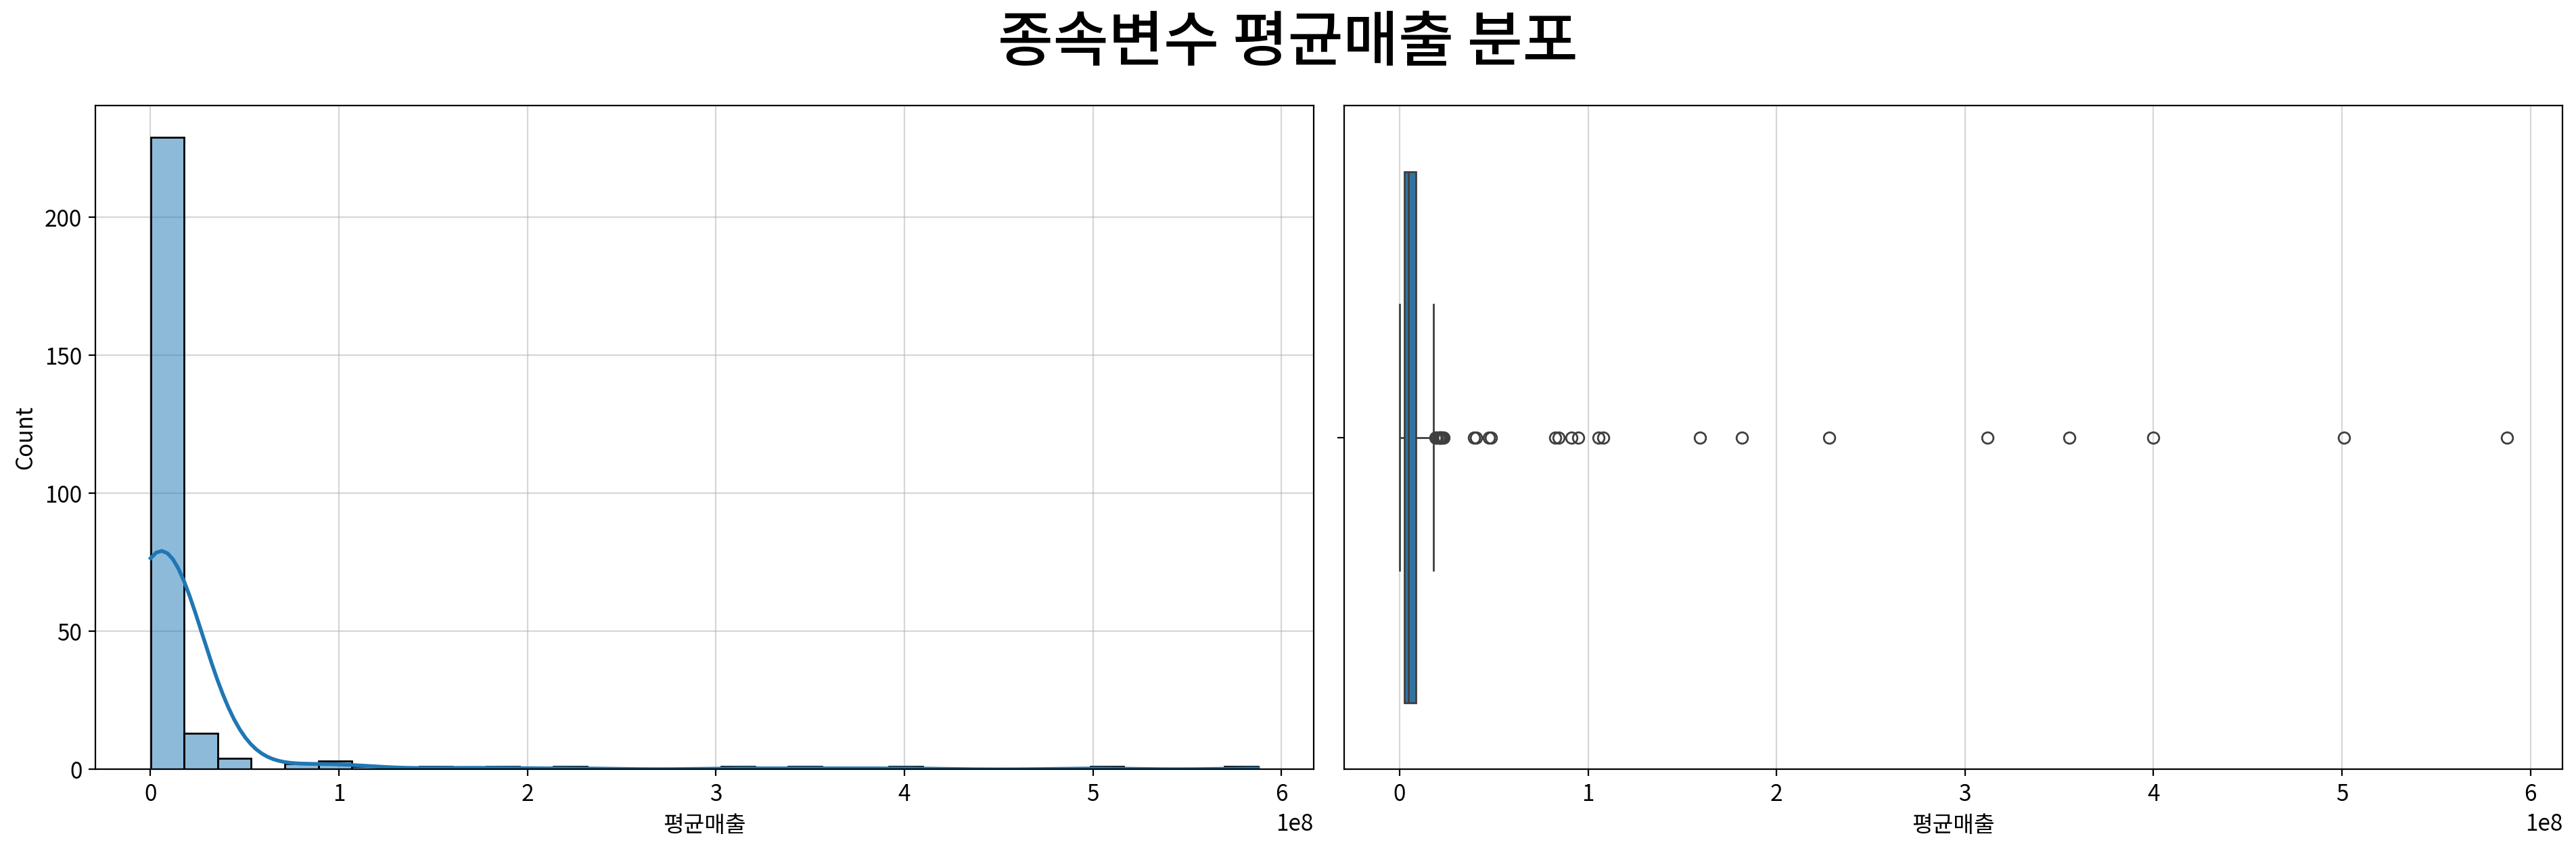

,평균매출
count,260
mean,18829866.649038
std,64402971.425538
min,78043.375
25%,2379390.260417
50%,4573823.541667
75%,8726342.947917
max,587586181.5
rel_diff,3.116876
rdiff_flag,large_diff


In [53]:
# 02. 단변량 분석
# 1. 연속형 종속변수에 대한 단변량 분석
# 1행 2열 서브플롯 구성
# -> 그래프 크기는 서브플롯 중 하나의 크기(전체 크기는 가로 960 x 2가 됨)
fig, ax = my_plot.init(rows=1, cols=2,
                       title=f"종속변수 {target} 분포", width=960, height=640)
my_plot.histplot(data=df2, x=target, kde=True, ax=ax[0])
my_plot.boxplot(data=df2, x=target, ax=ax[1])
my_plot.show()

# 연속형 변수 기술통계량에서 종속변수에 대한 부분만 추출
num_desc[num_desc.index == target].T

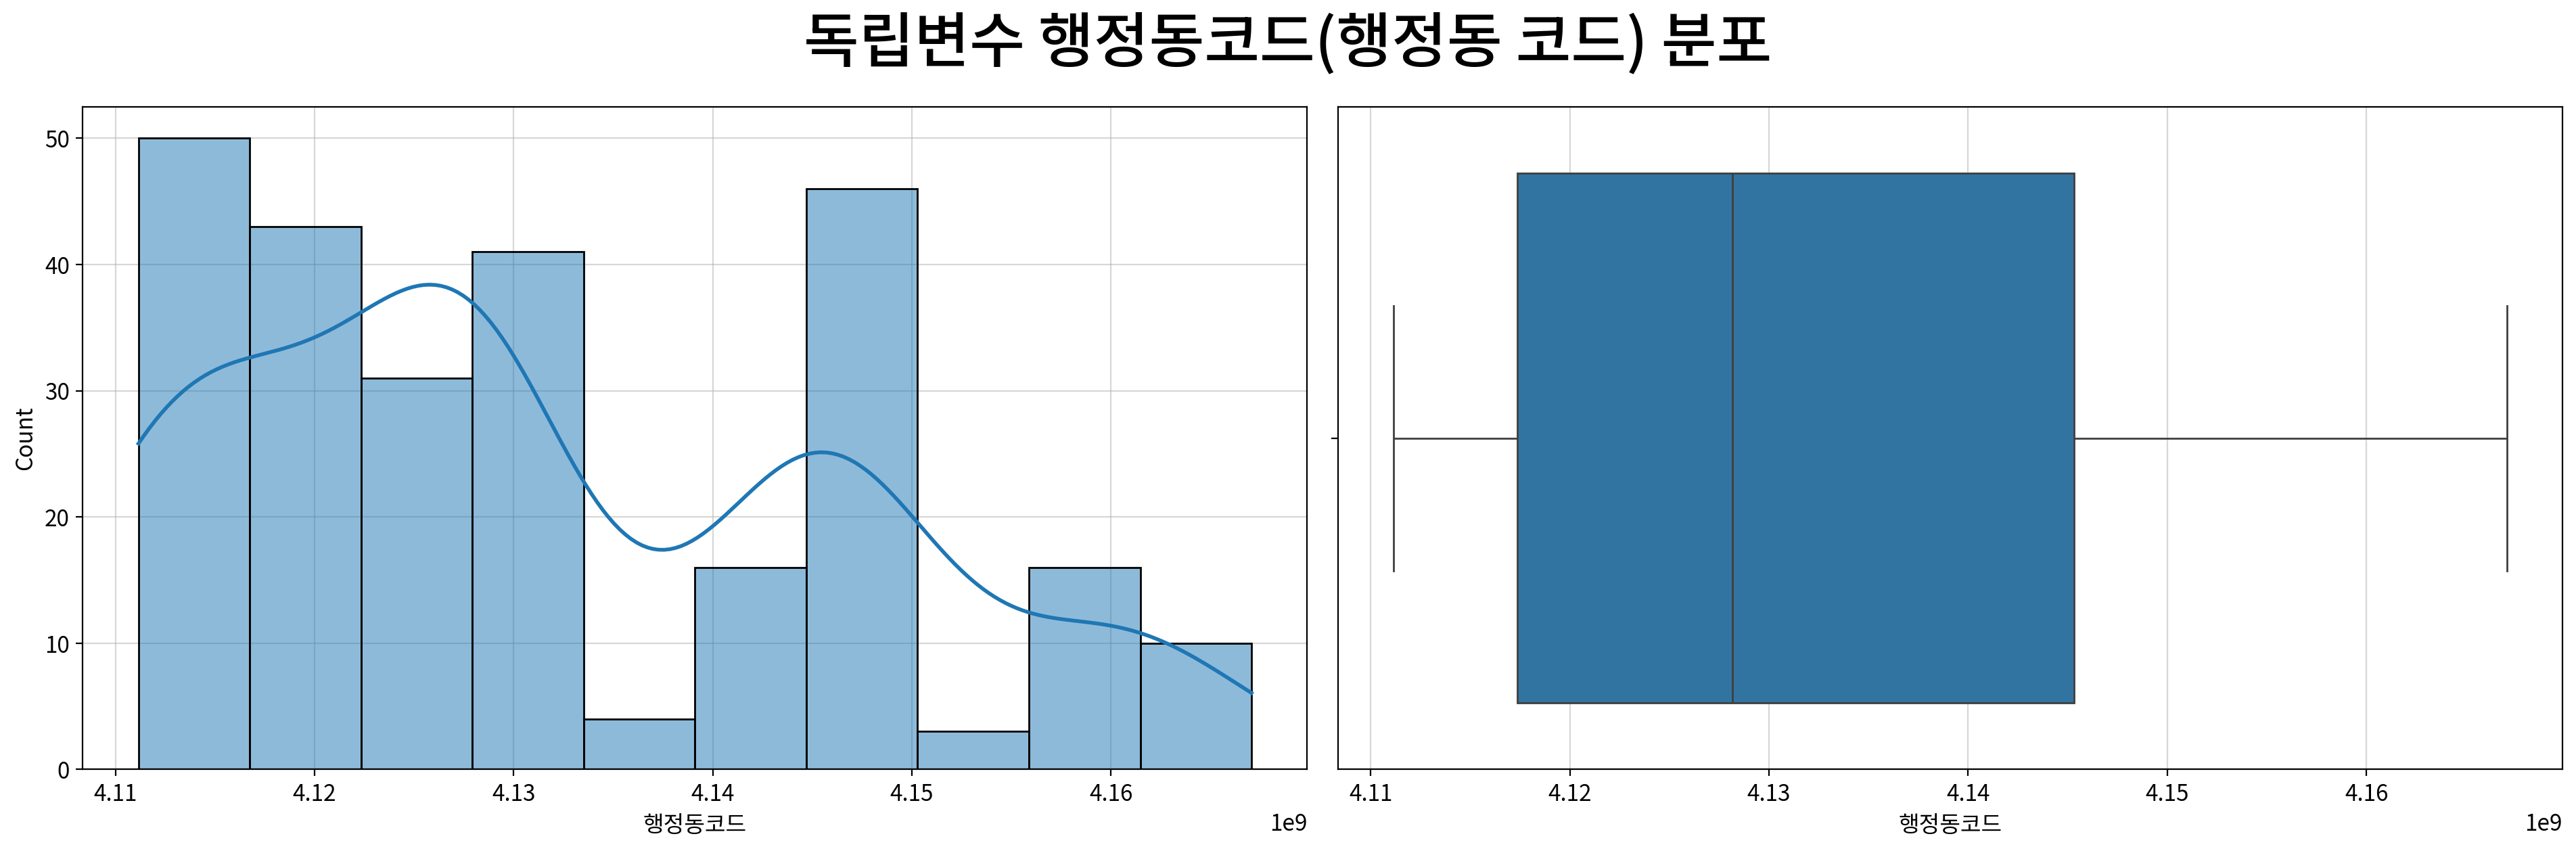

,행정동코드
count,260
mean,4131567895.384615
std,15619665.534937
min,4111156000.0
25%,4117358750.0
50%,4128157000.0
75%,4145334250.0
max,4167053000.0
rel_diff,0.000826
rdiff_flag,similar


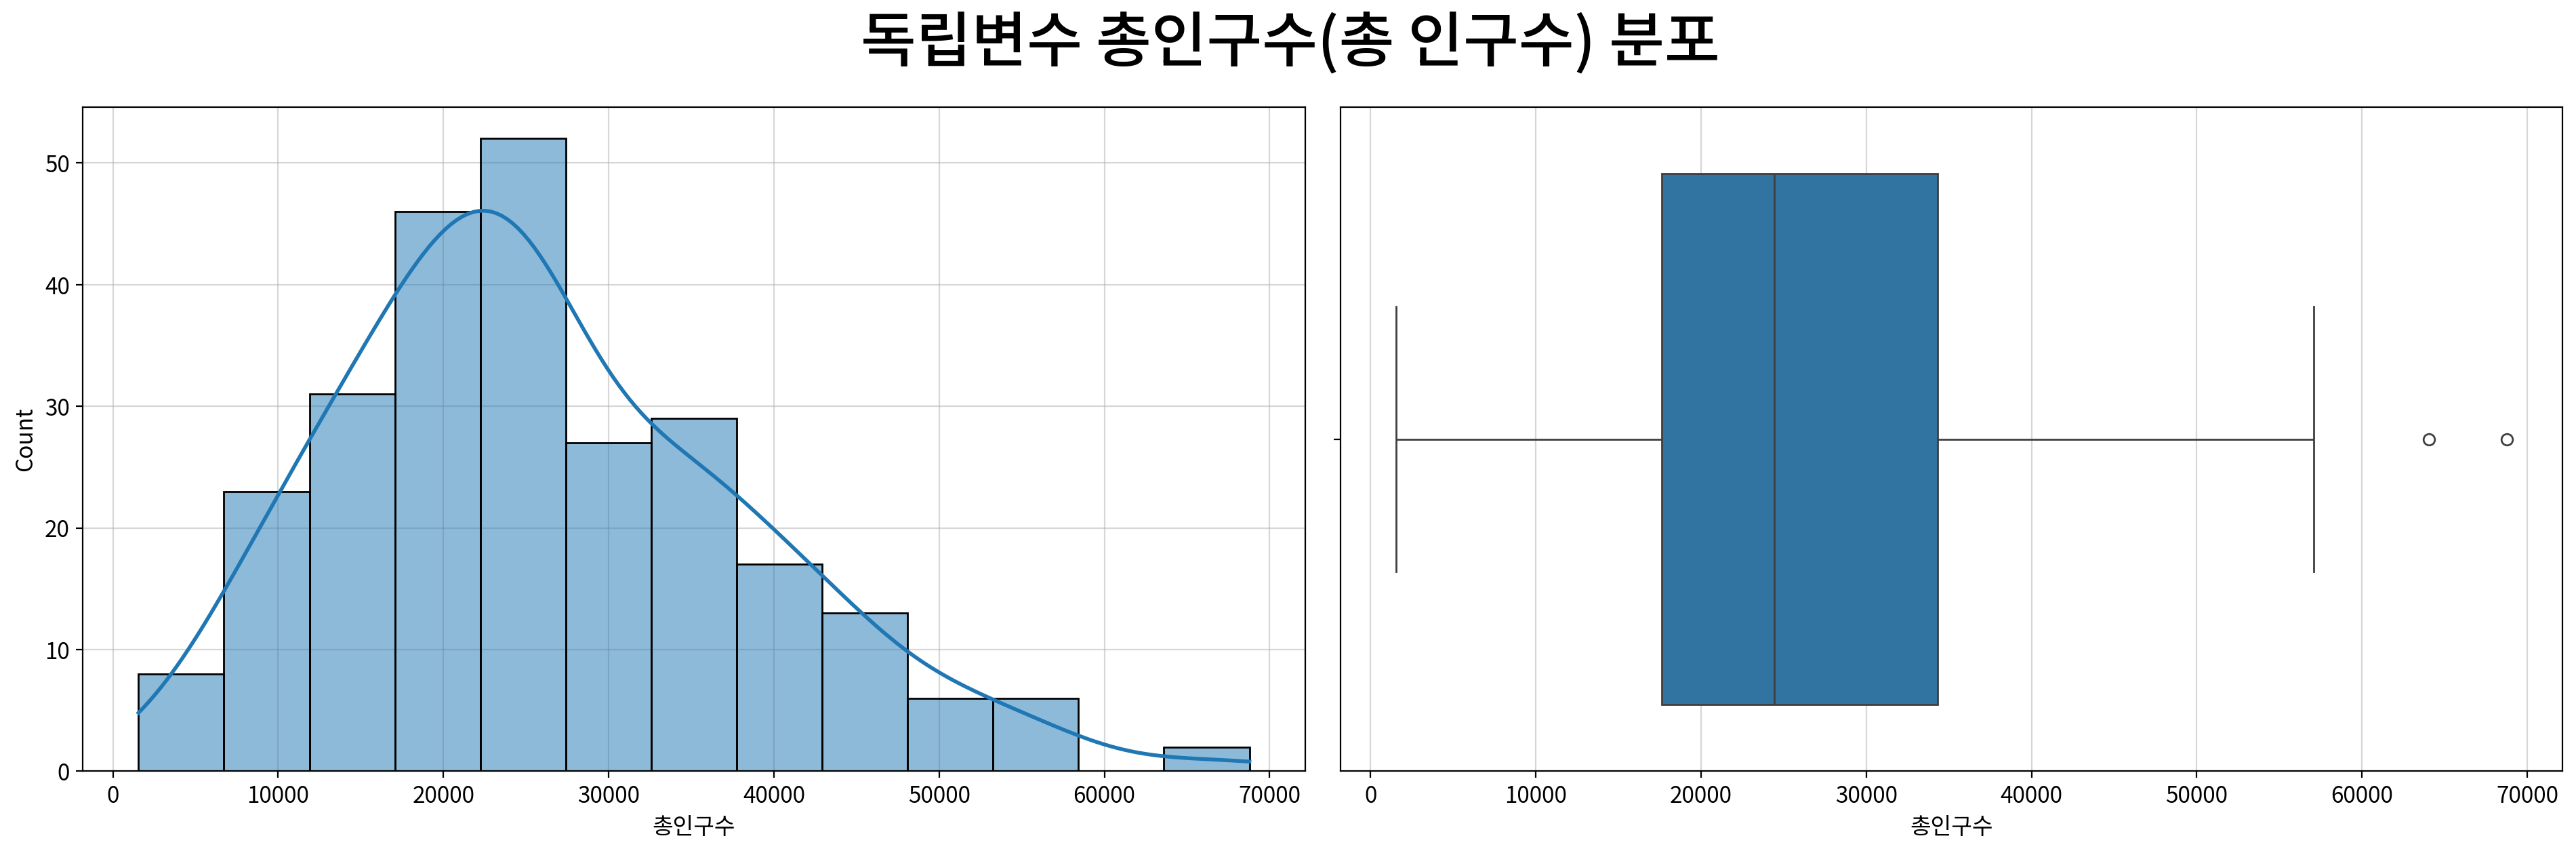

,총인구수
count,260
mean,26059.542468
std,12292.961871
min,1547.625
25%,17613.572917
50%,24441.0
75%,34314.697917
max,68779.125
rel_diff,0.066222
rdiff_flag,similar


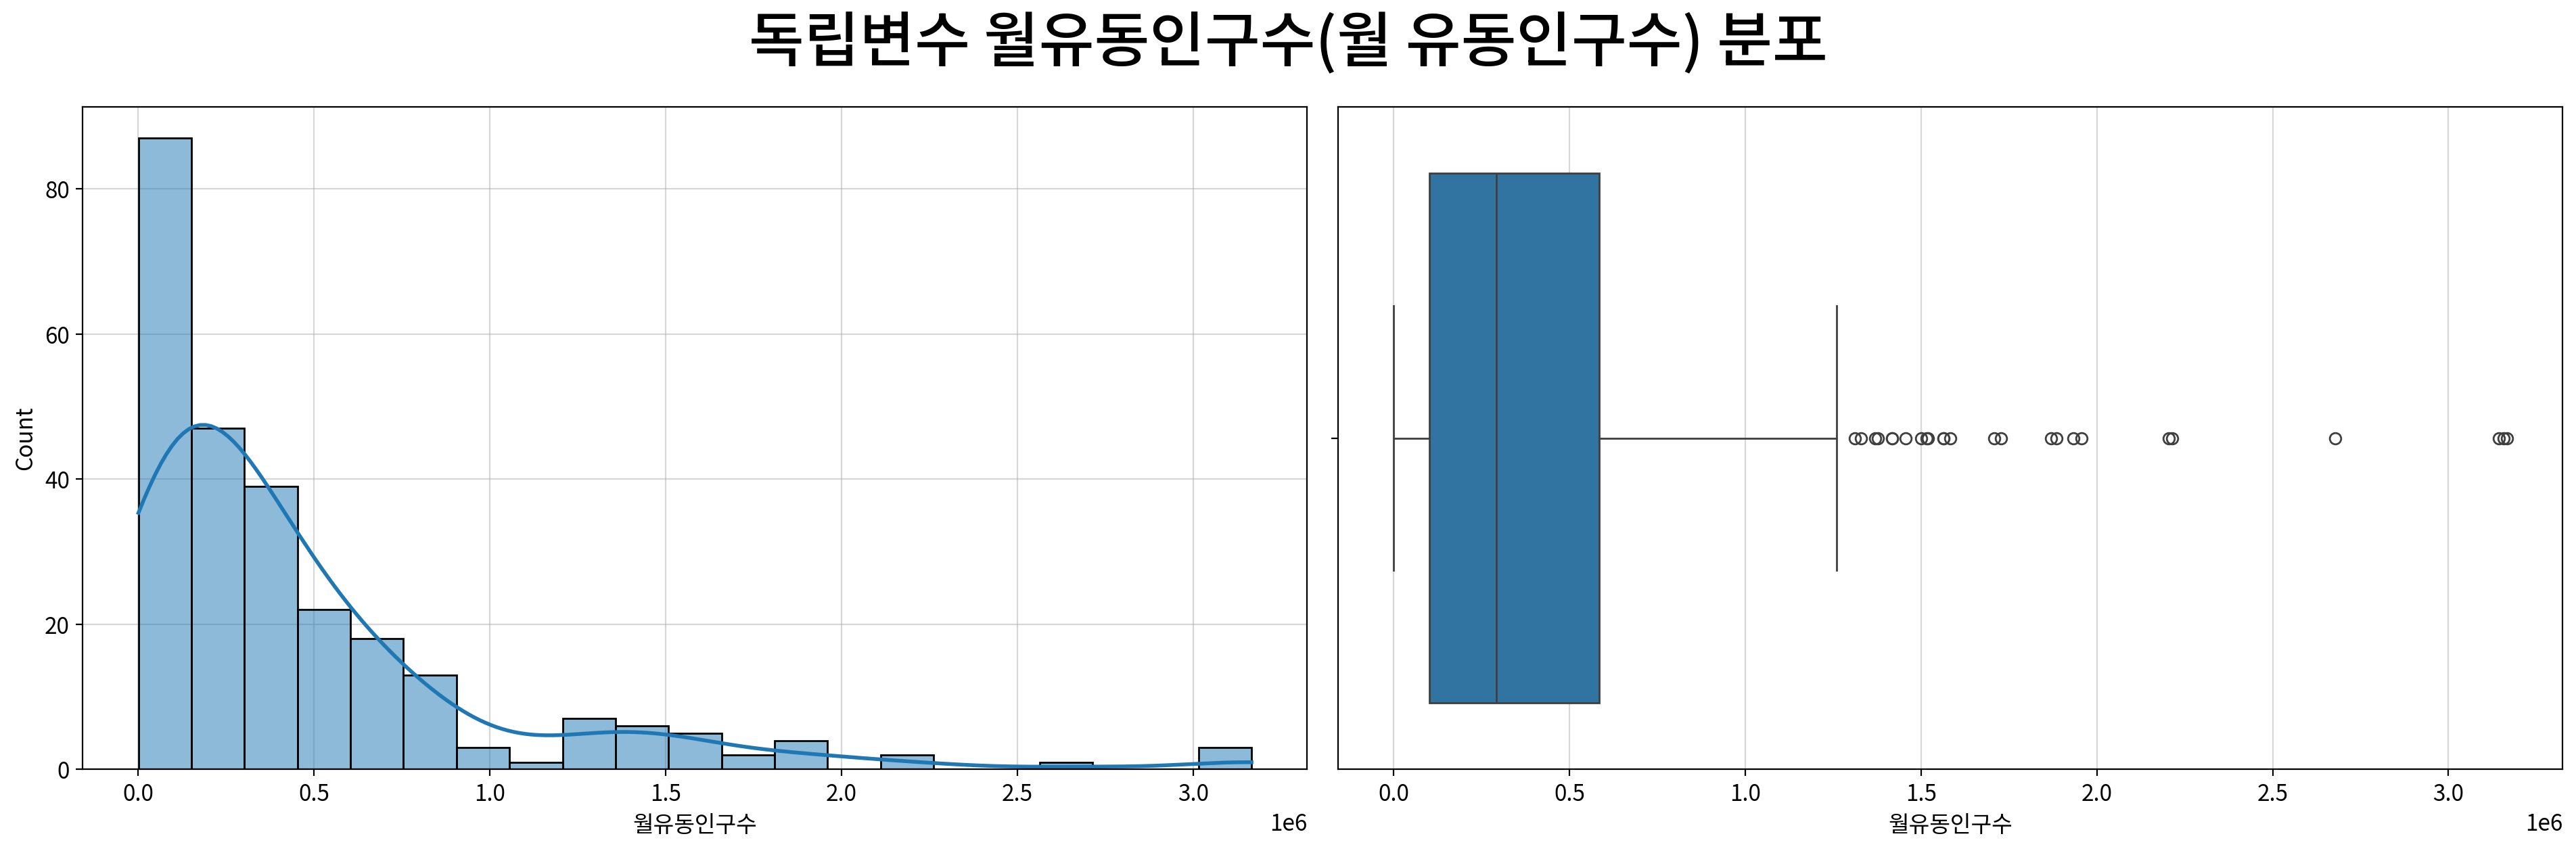

,월유동인구수
count,260
mean,468258.3433
std,557102.008295
min,737.935417
25%,102383.758958
50%,292525.3975
75%,585338.936458
max,3165938.191667
rel_diff,0.600744
rdiff_flag,large_diff


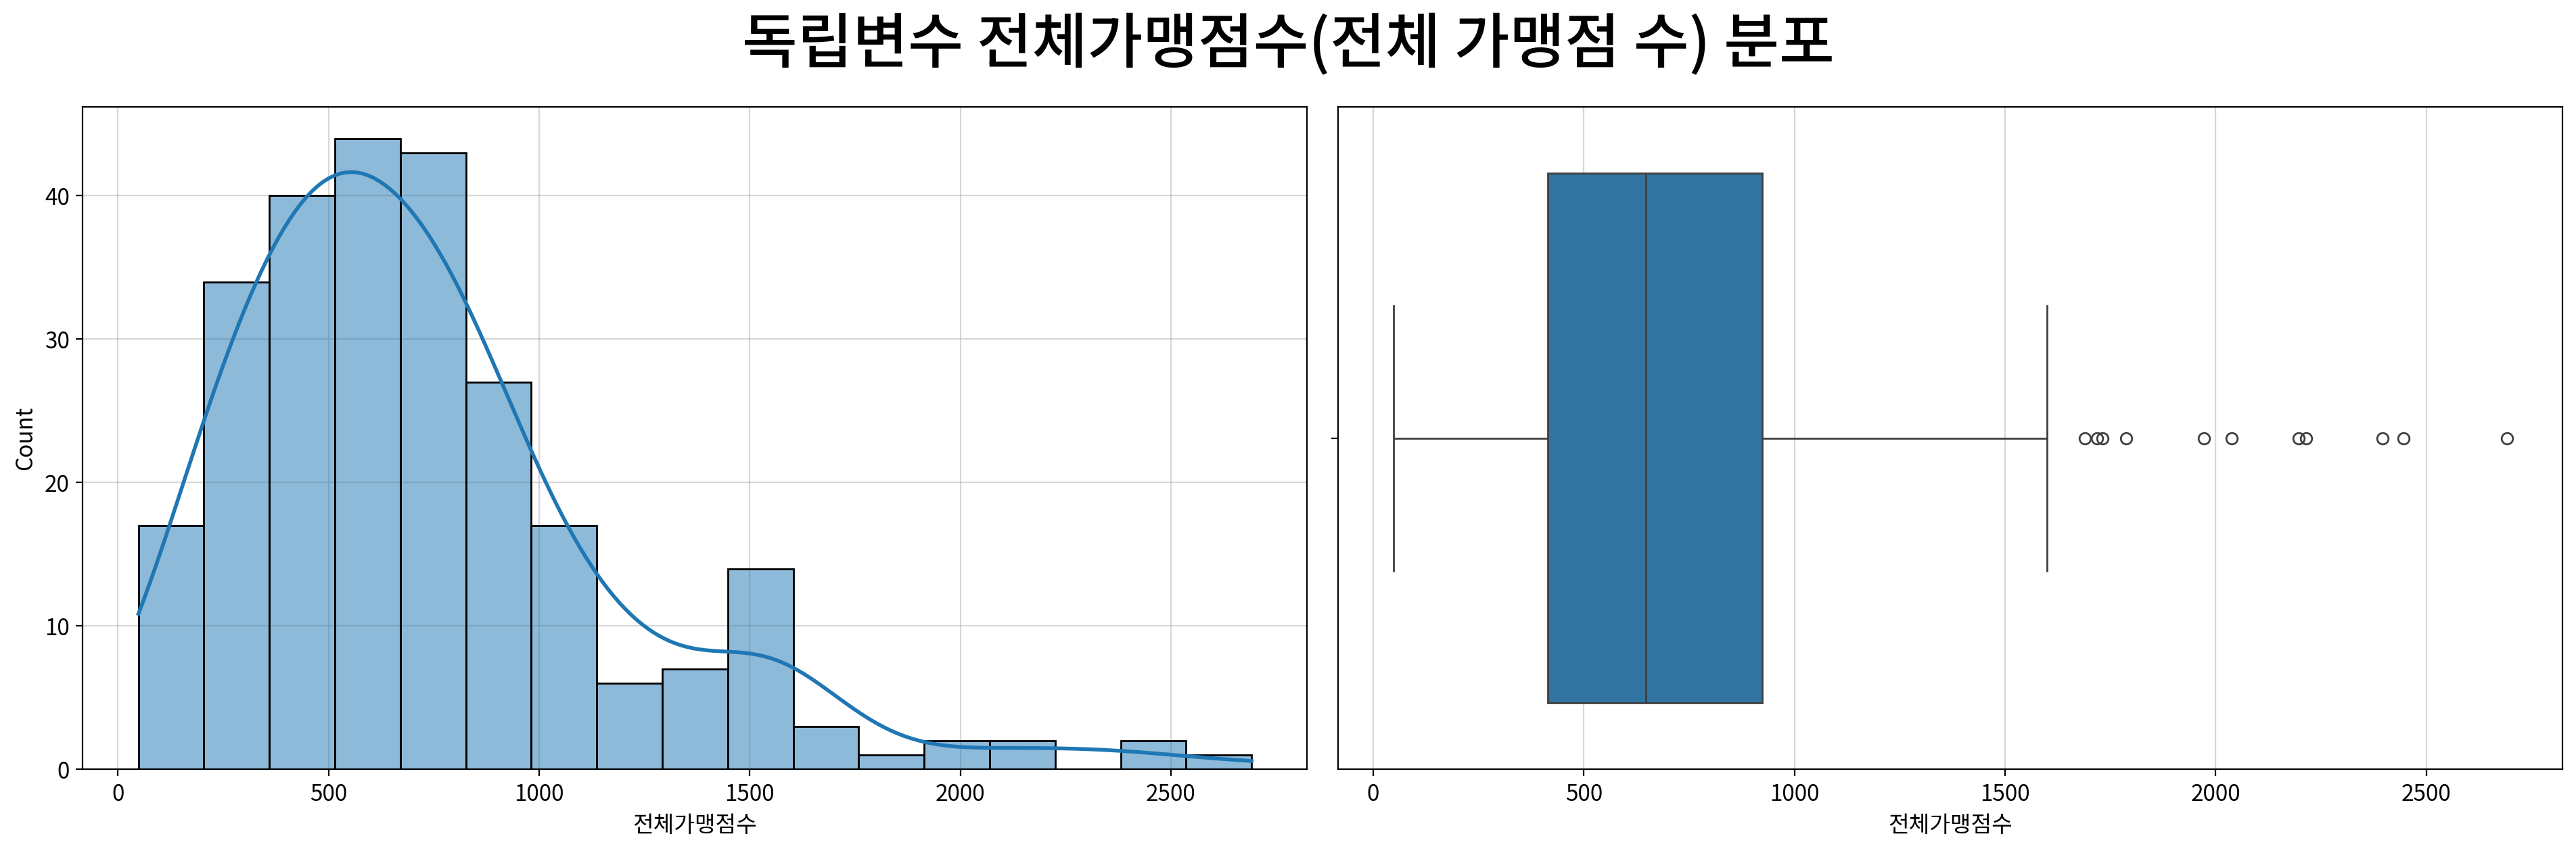

,전체가맹점수
count,260
mean,732.339744
std,458.936871
min,48.666667
25%,413.75
50%,647.833333
75%,923.583333
max,2691.333333
rel_diff,0.130445
rdiff_flag,diff


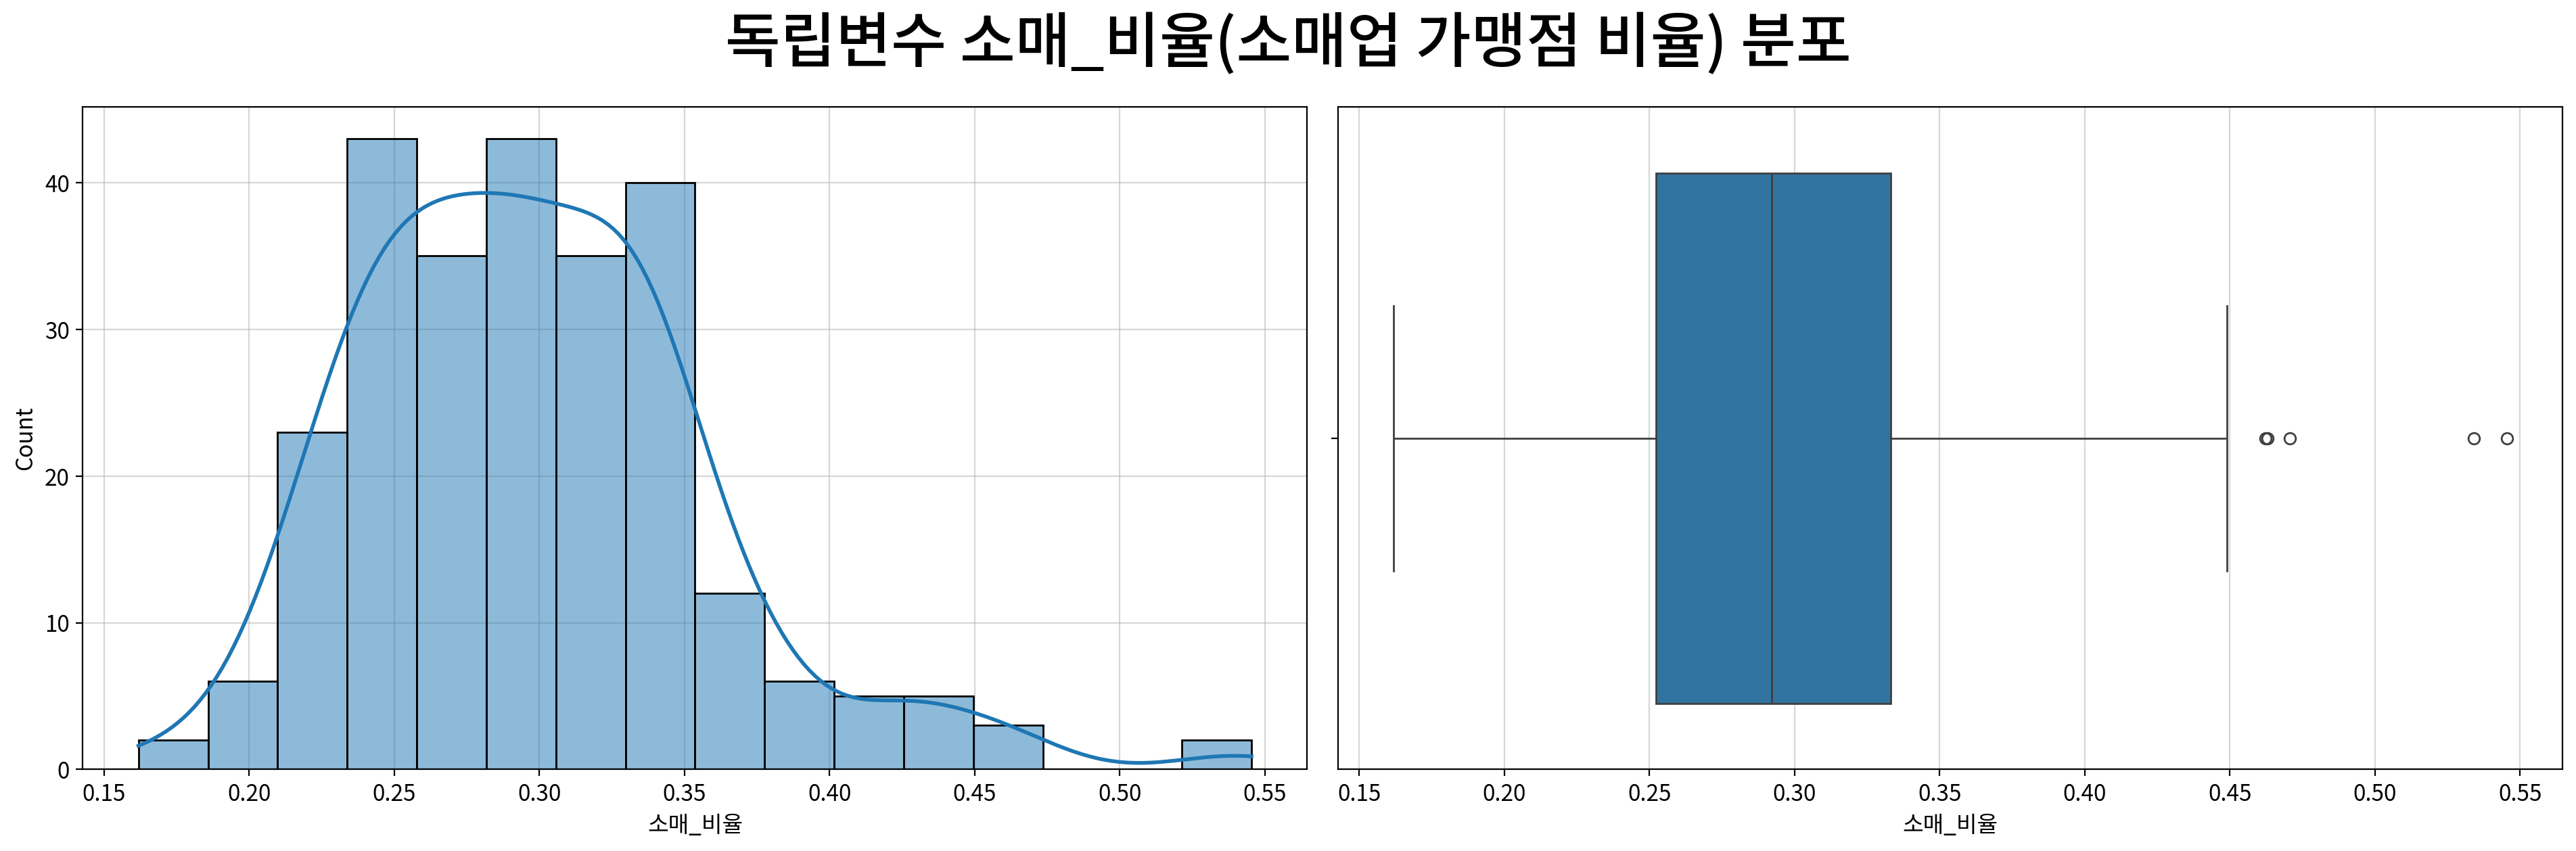

,소매_비율
count,260
mean,0.297994
std,0.060206
min,0.161889
25%,0.252321
50%,0.292161
75%,0.333016
max,0.545416
rel_diff,0.019963
rdiff_flag,similar


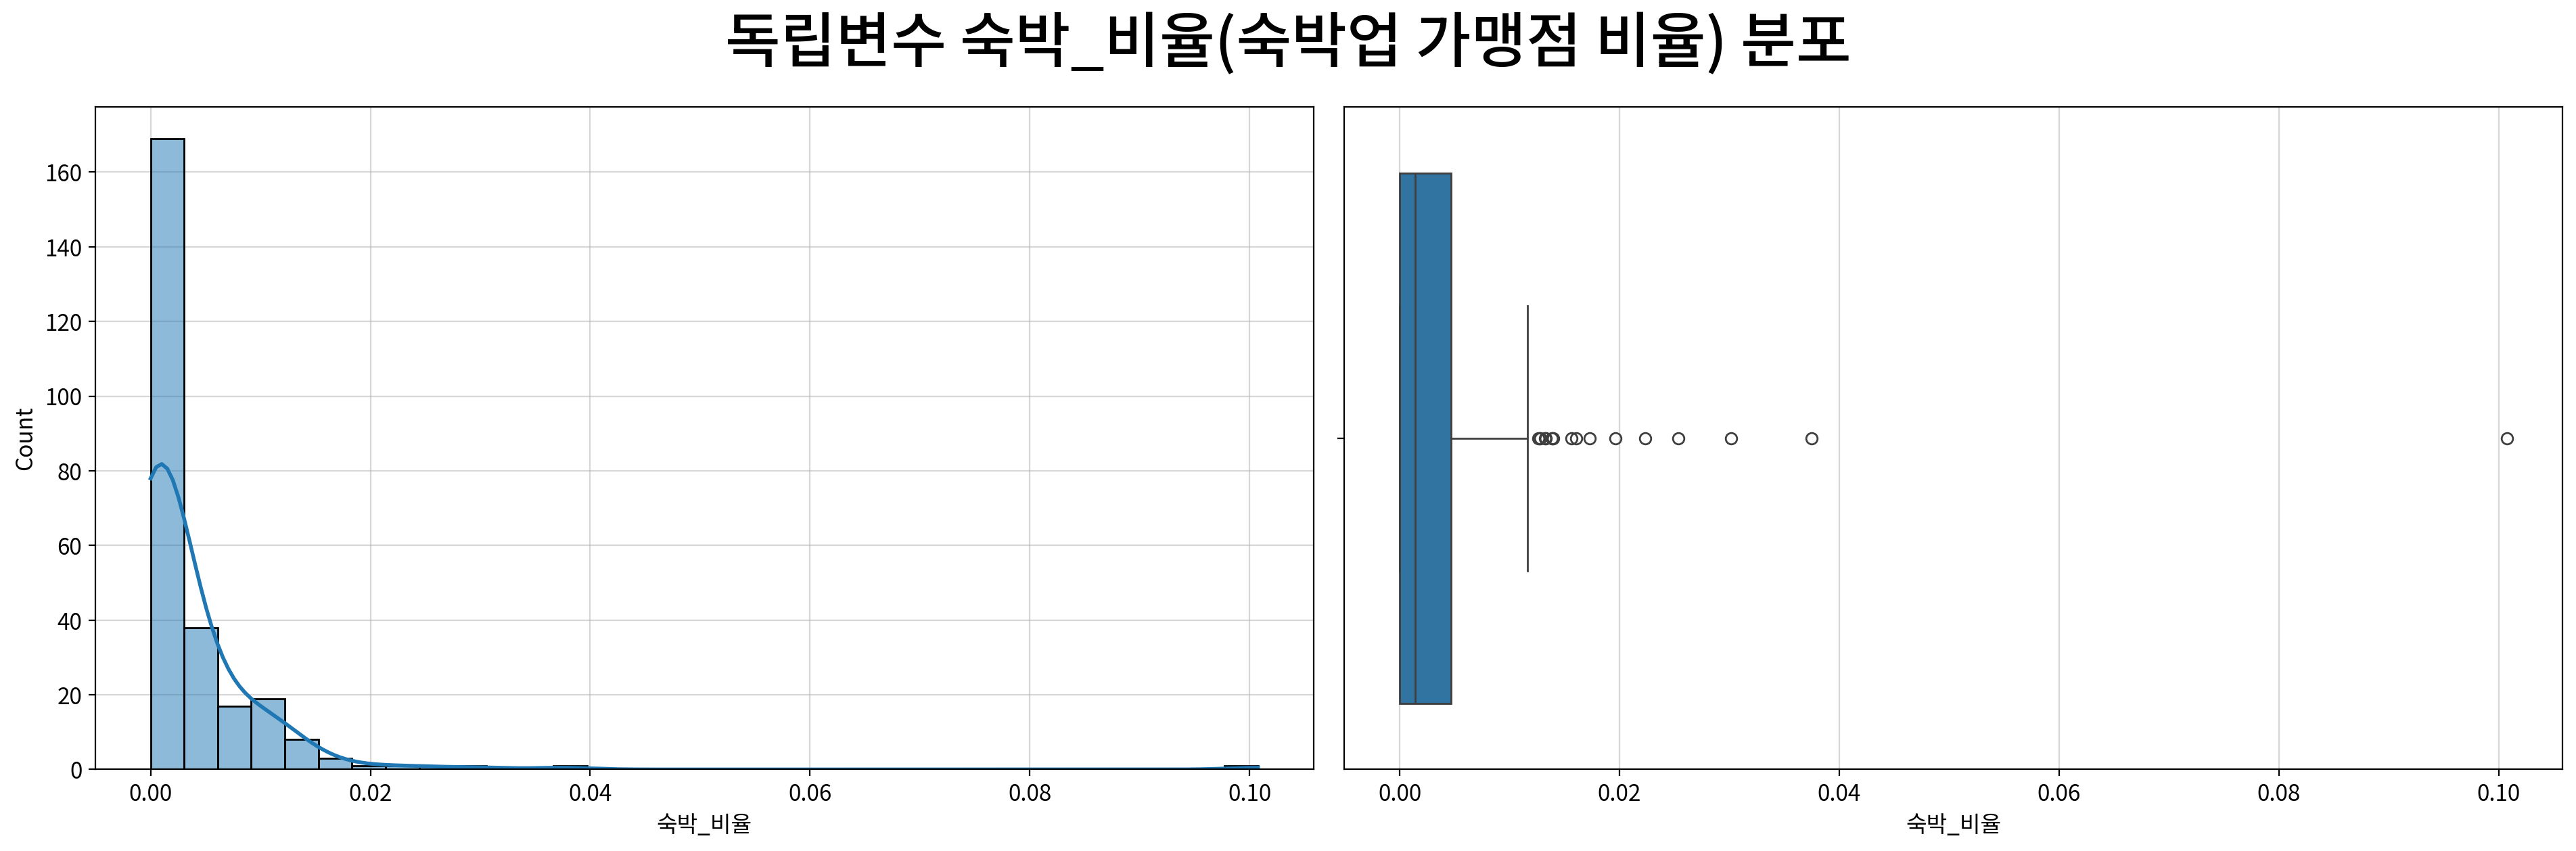

,숙박_비율
count,260
mean,0.003756
std,0.007972
min,0.0
25%,0.0
50%,0.00141
75%,0.004702
max,0.10077
rel_diff,1.6646
rdiff_flag,large_diff


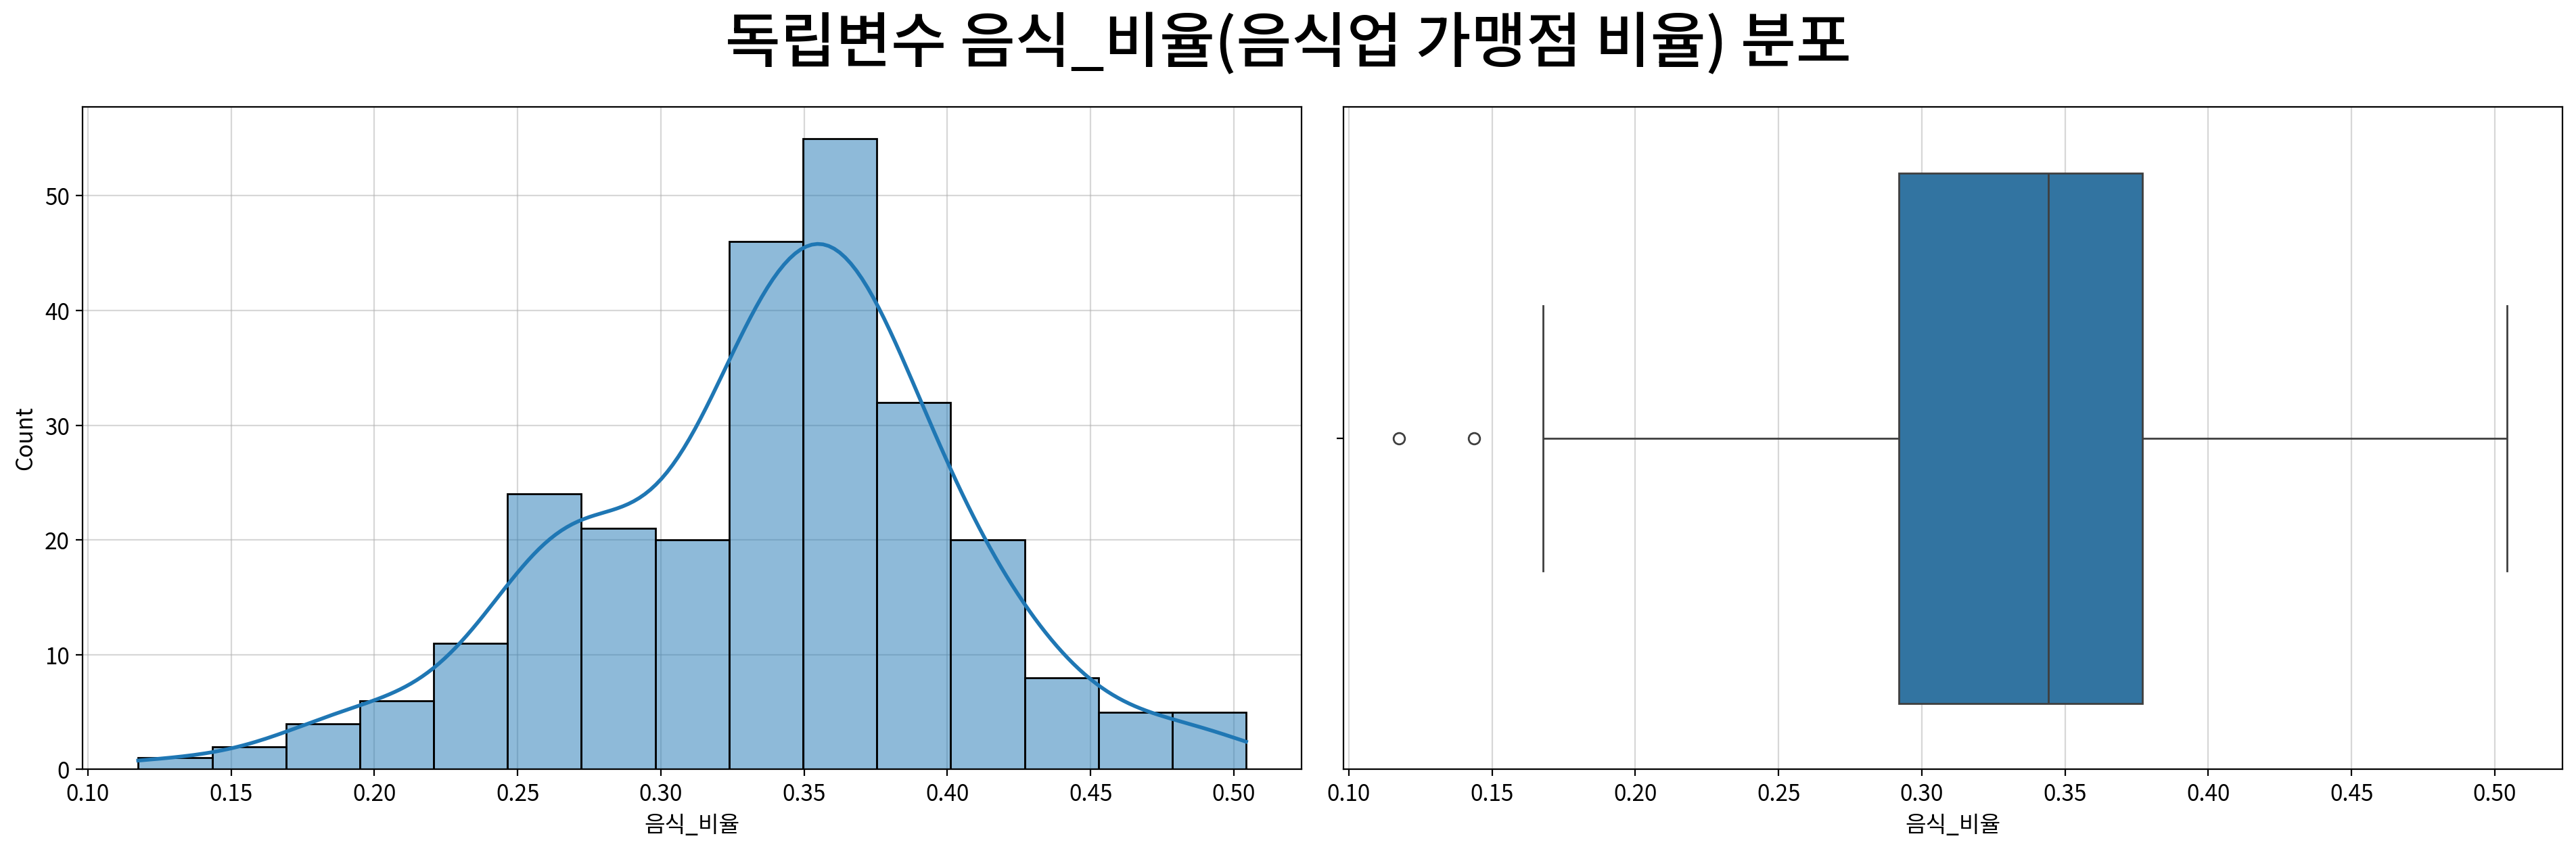

,음식_비율
count,260
mean,0.336644
std,0.066666
min,0.117562
25%,0.291881
50%,0.344203
75%,0.376898
max,0.504281
rel_diff,0.021959
rdiff_flag,similar


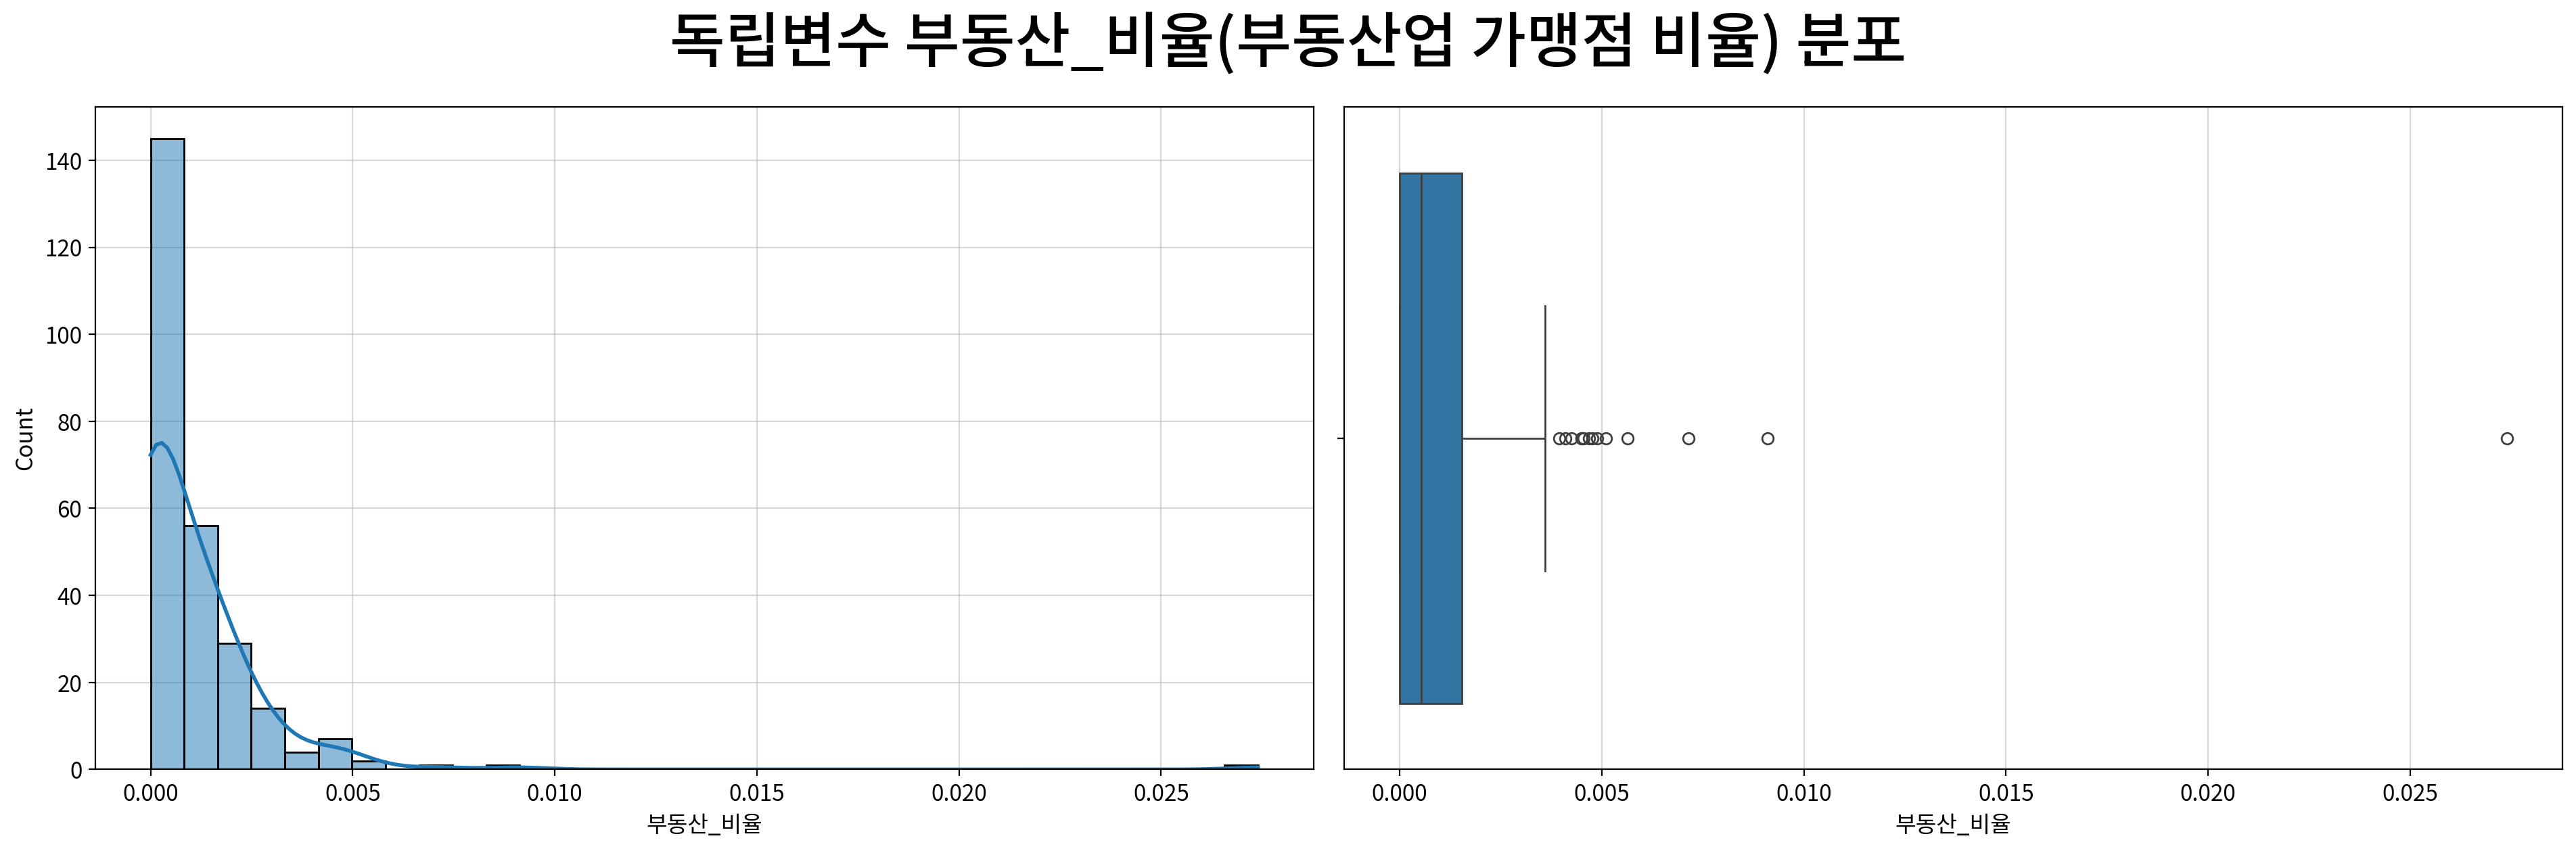

,부동산_비율
count,260
mean,0.001076
std,0.002125
min,0.0
25%,0.0
50%,0.000535
75%,0.001532
max,0.027397
rel_diff,1.011761
rdiff_flag,large_diff


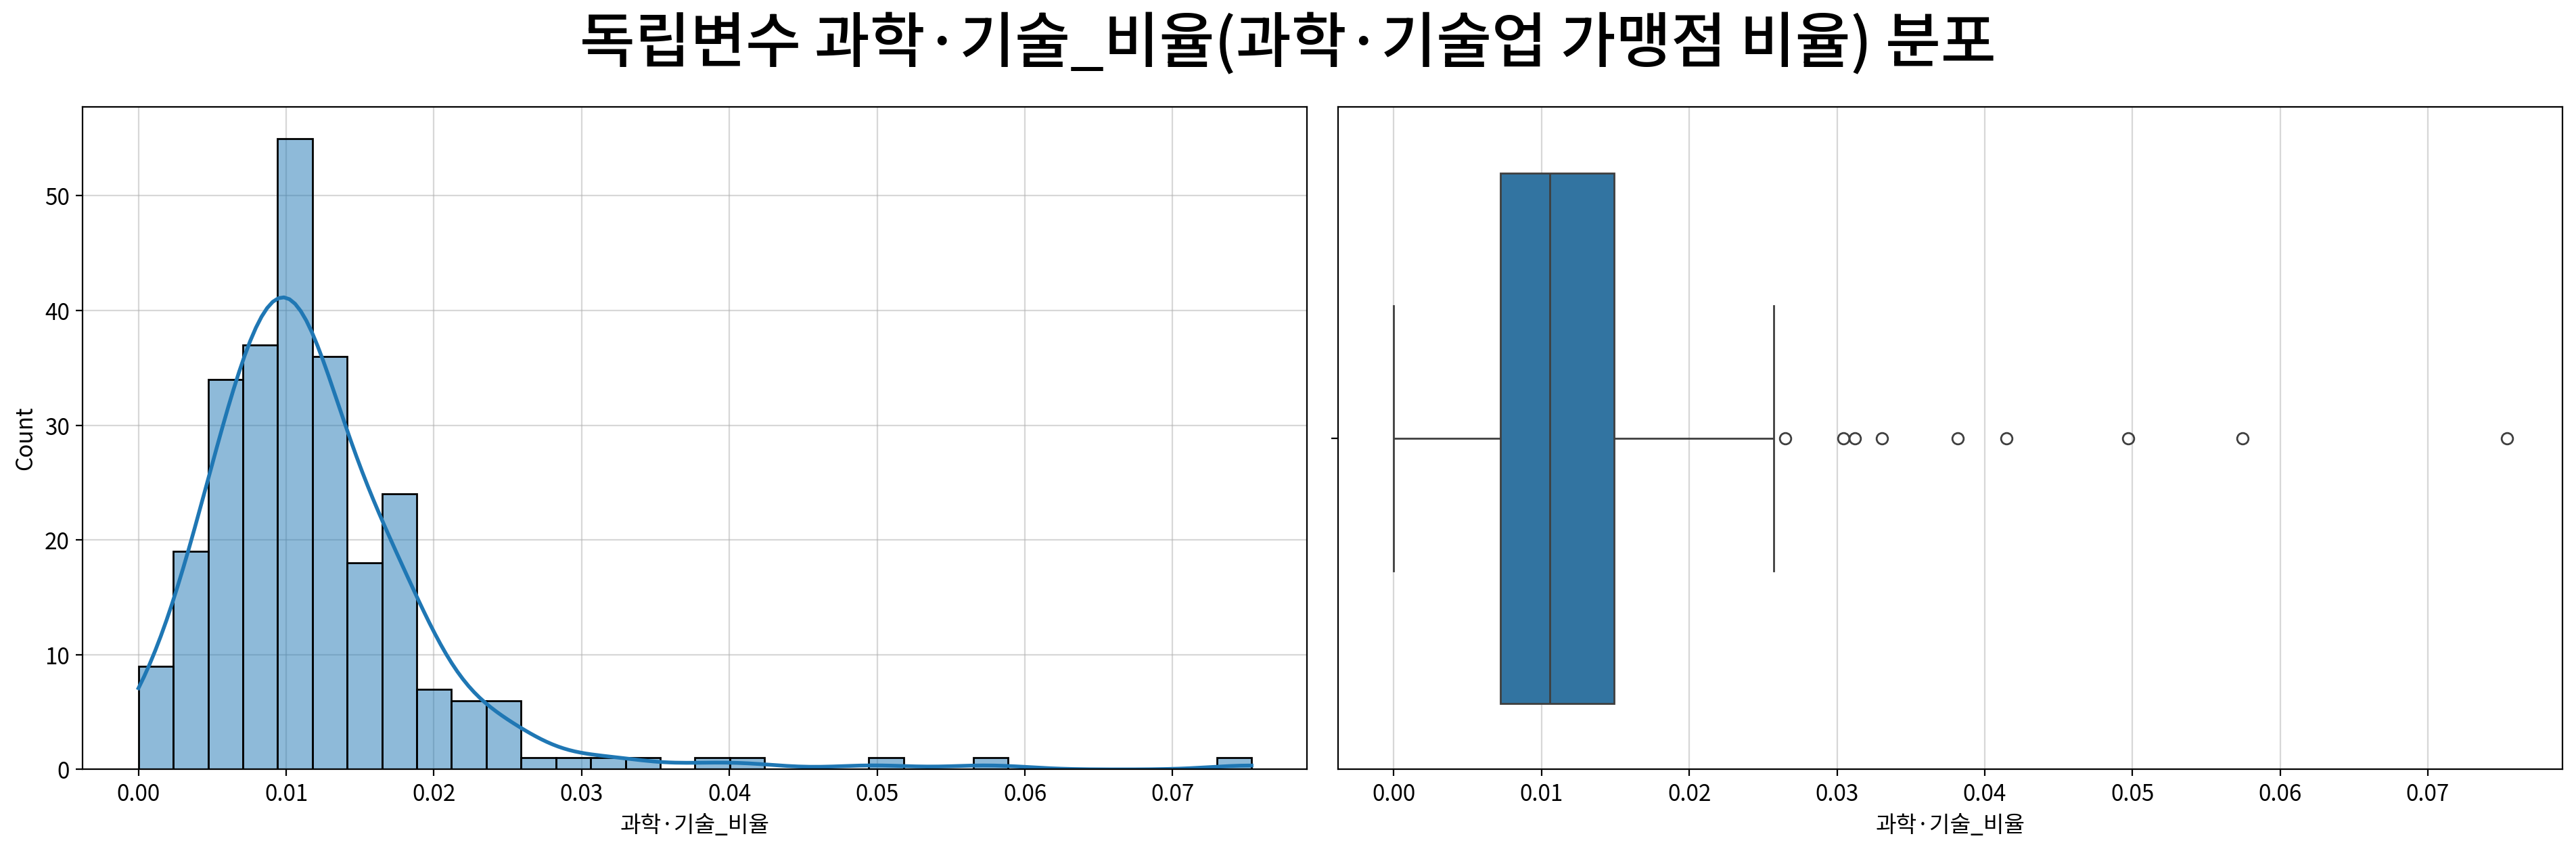

,과학·기술_비율
count,260
mean,0.012022
std,0.008338
min,0.0
25%,0.007234
50%,0.010557
75%,0.01489
max,0.075342
rel_diff,0.138794
rdiff_flag,diff


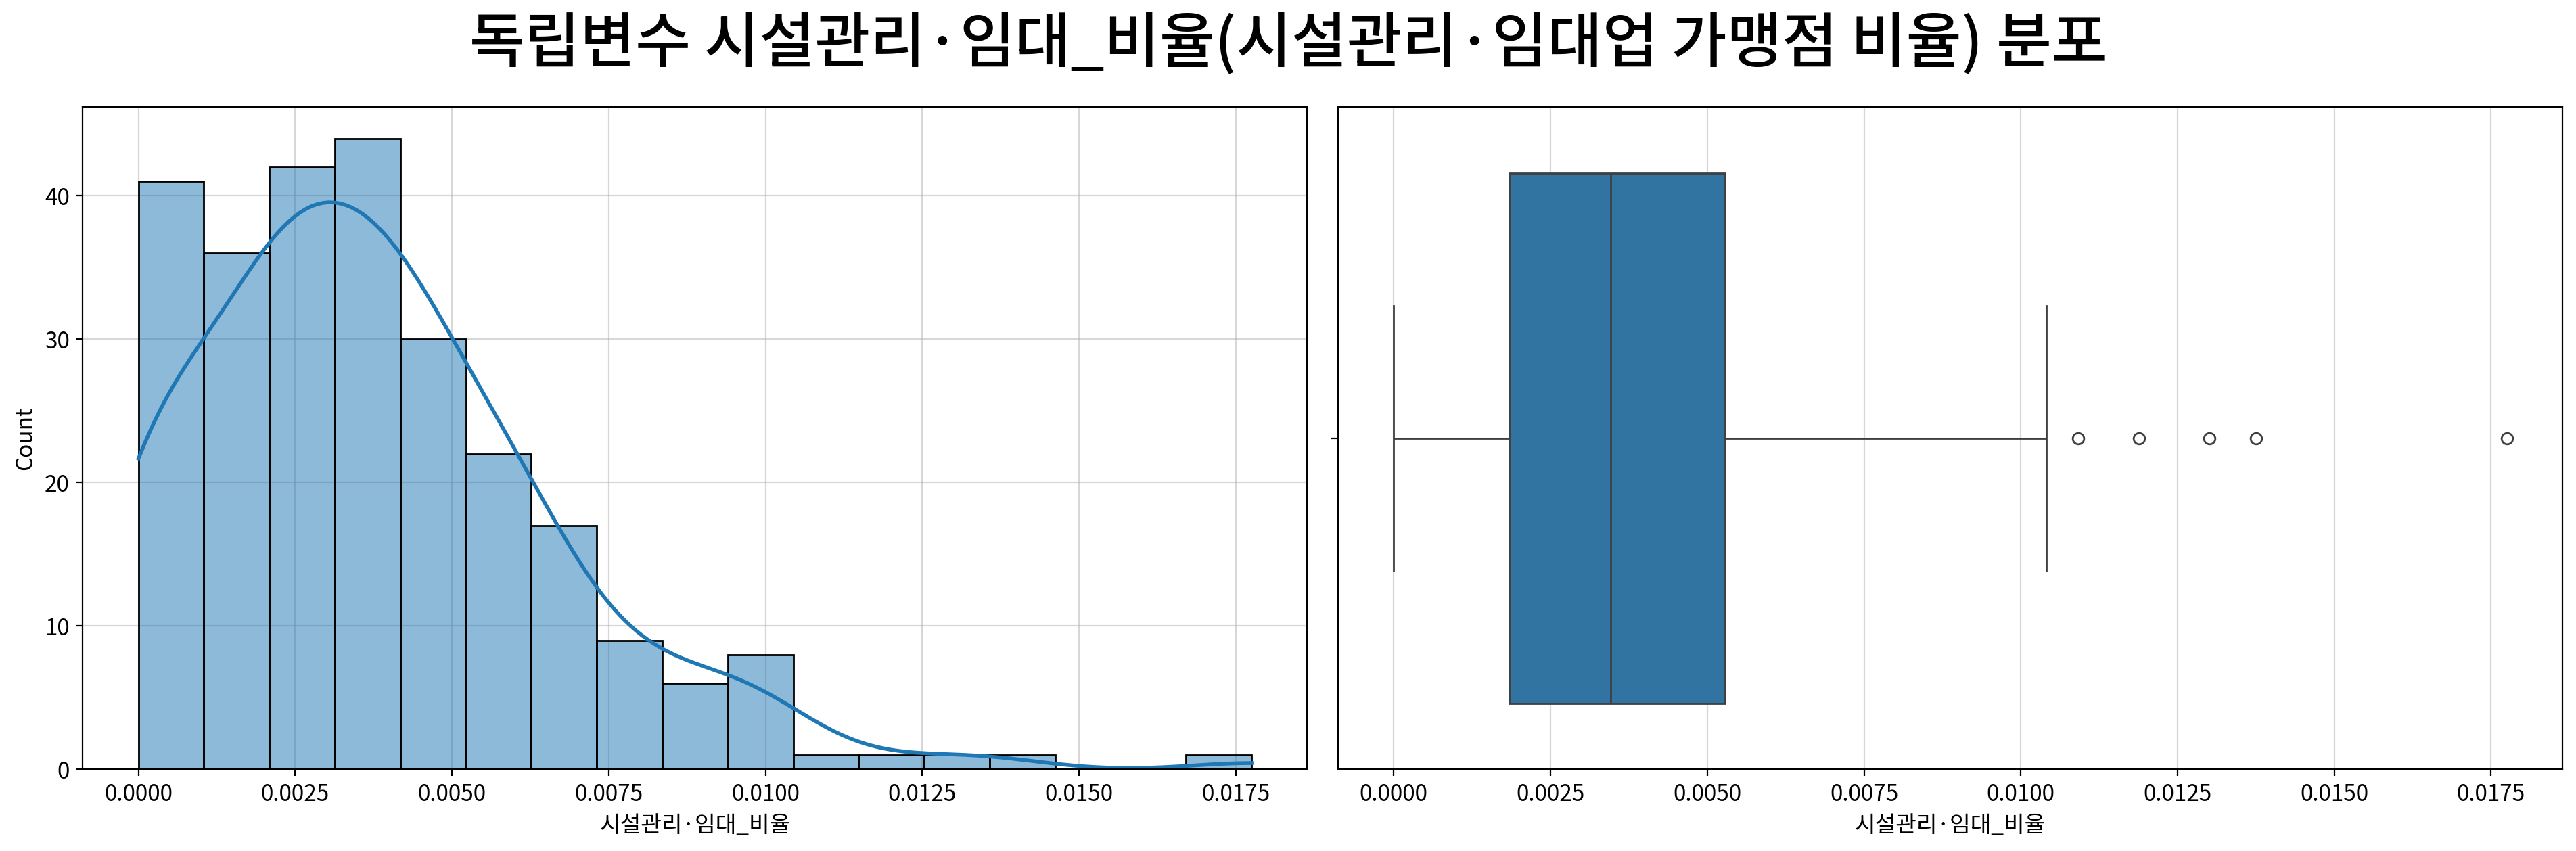

,시설관리·임대_비율
count,260
mean,0.003804
std,0.002871
min,0.0
25%,0.001843
50%,0.003463
75%,0.005284
max,0.017751
rel_diff,0.098262
rdiff_flag,similar


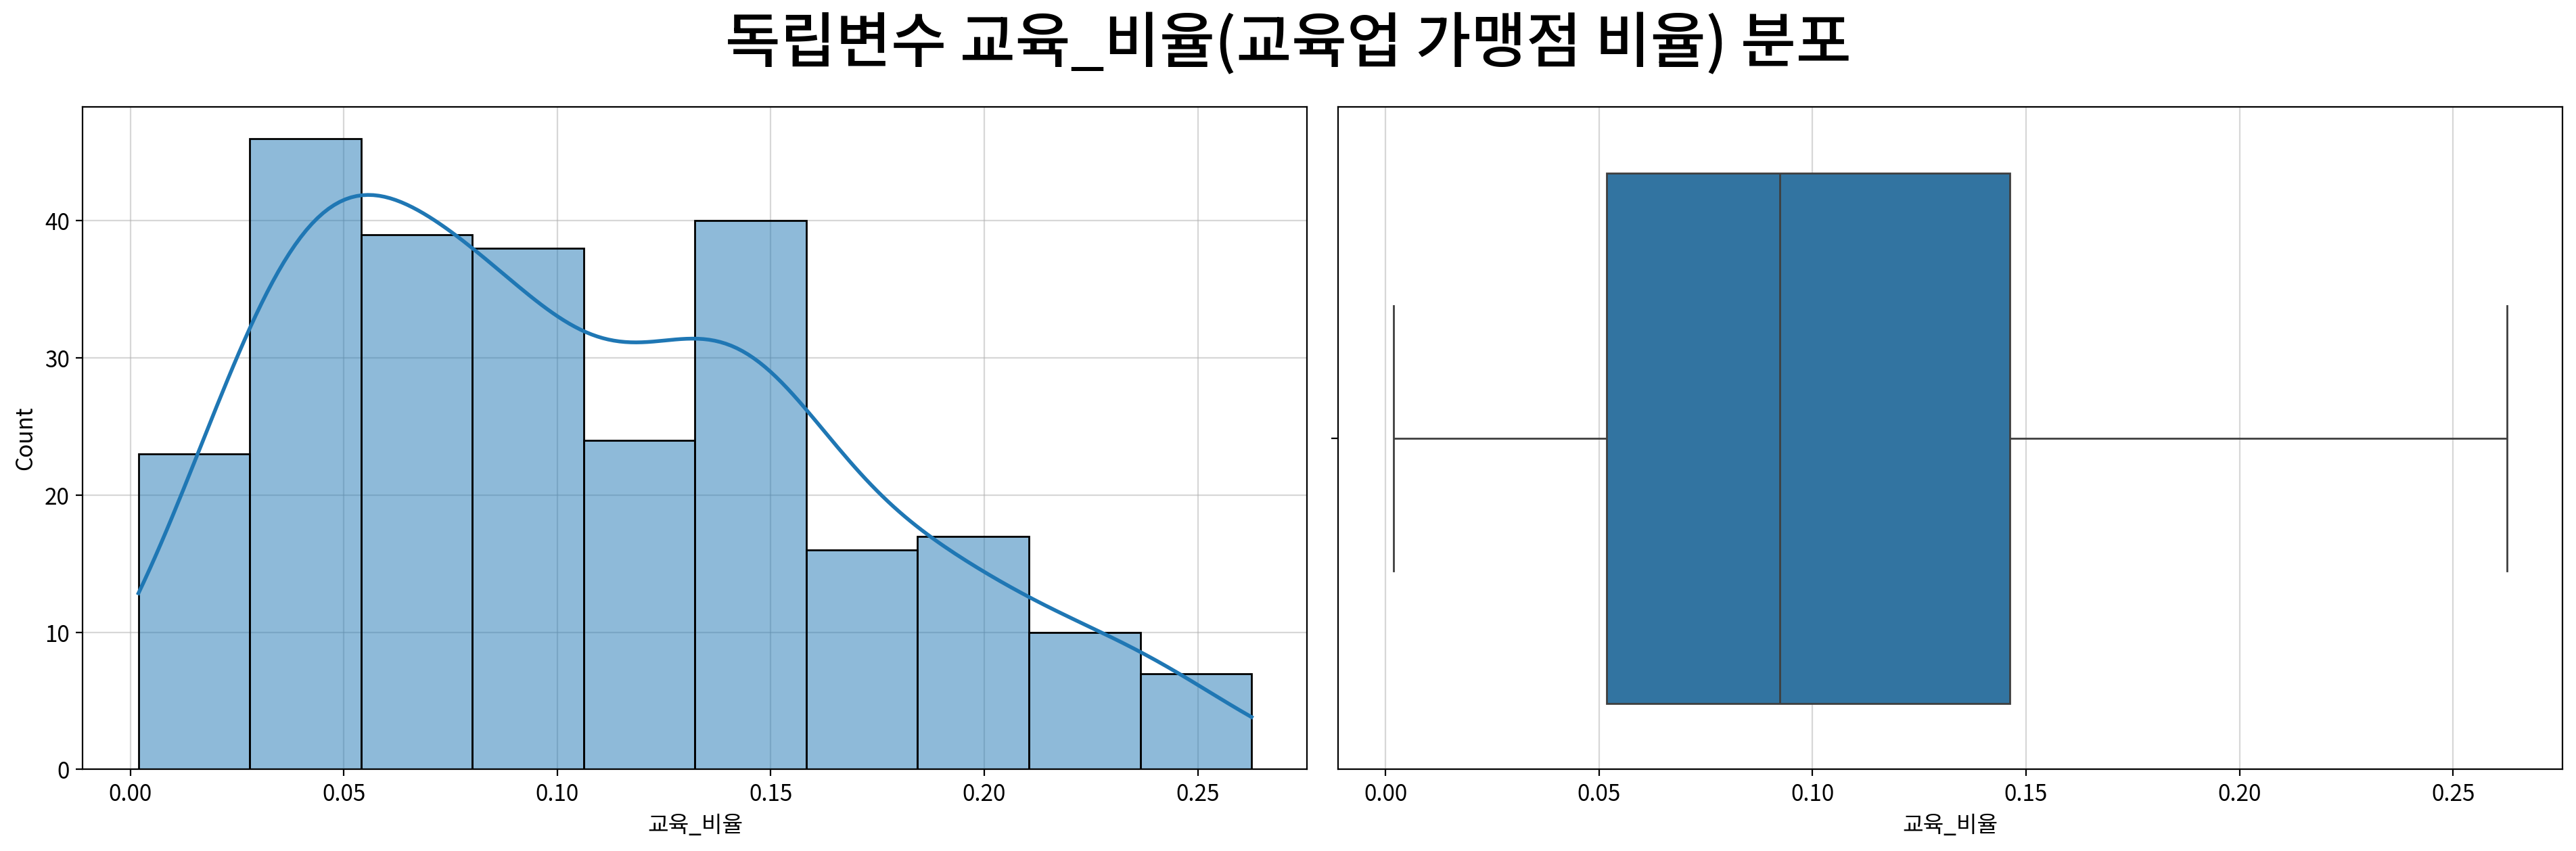

,교육_비율
count,260
mean,0.103935
std,0.062281
min,0.001916
25%,0.051701
50%,0.09231
75%,0.146204
max,0.262603
rel_diff,0.125938
rdiff_flag,diff


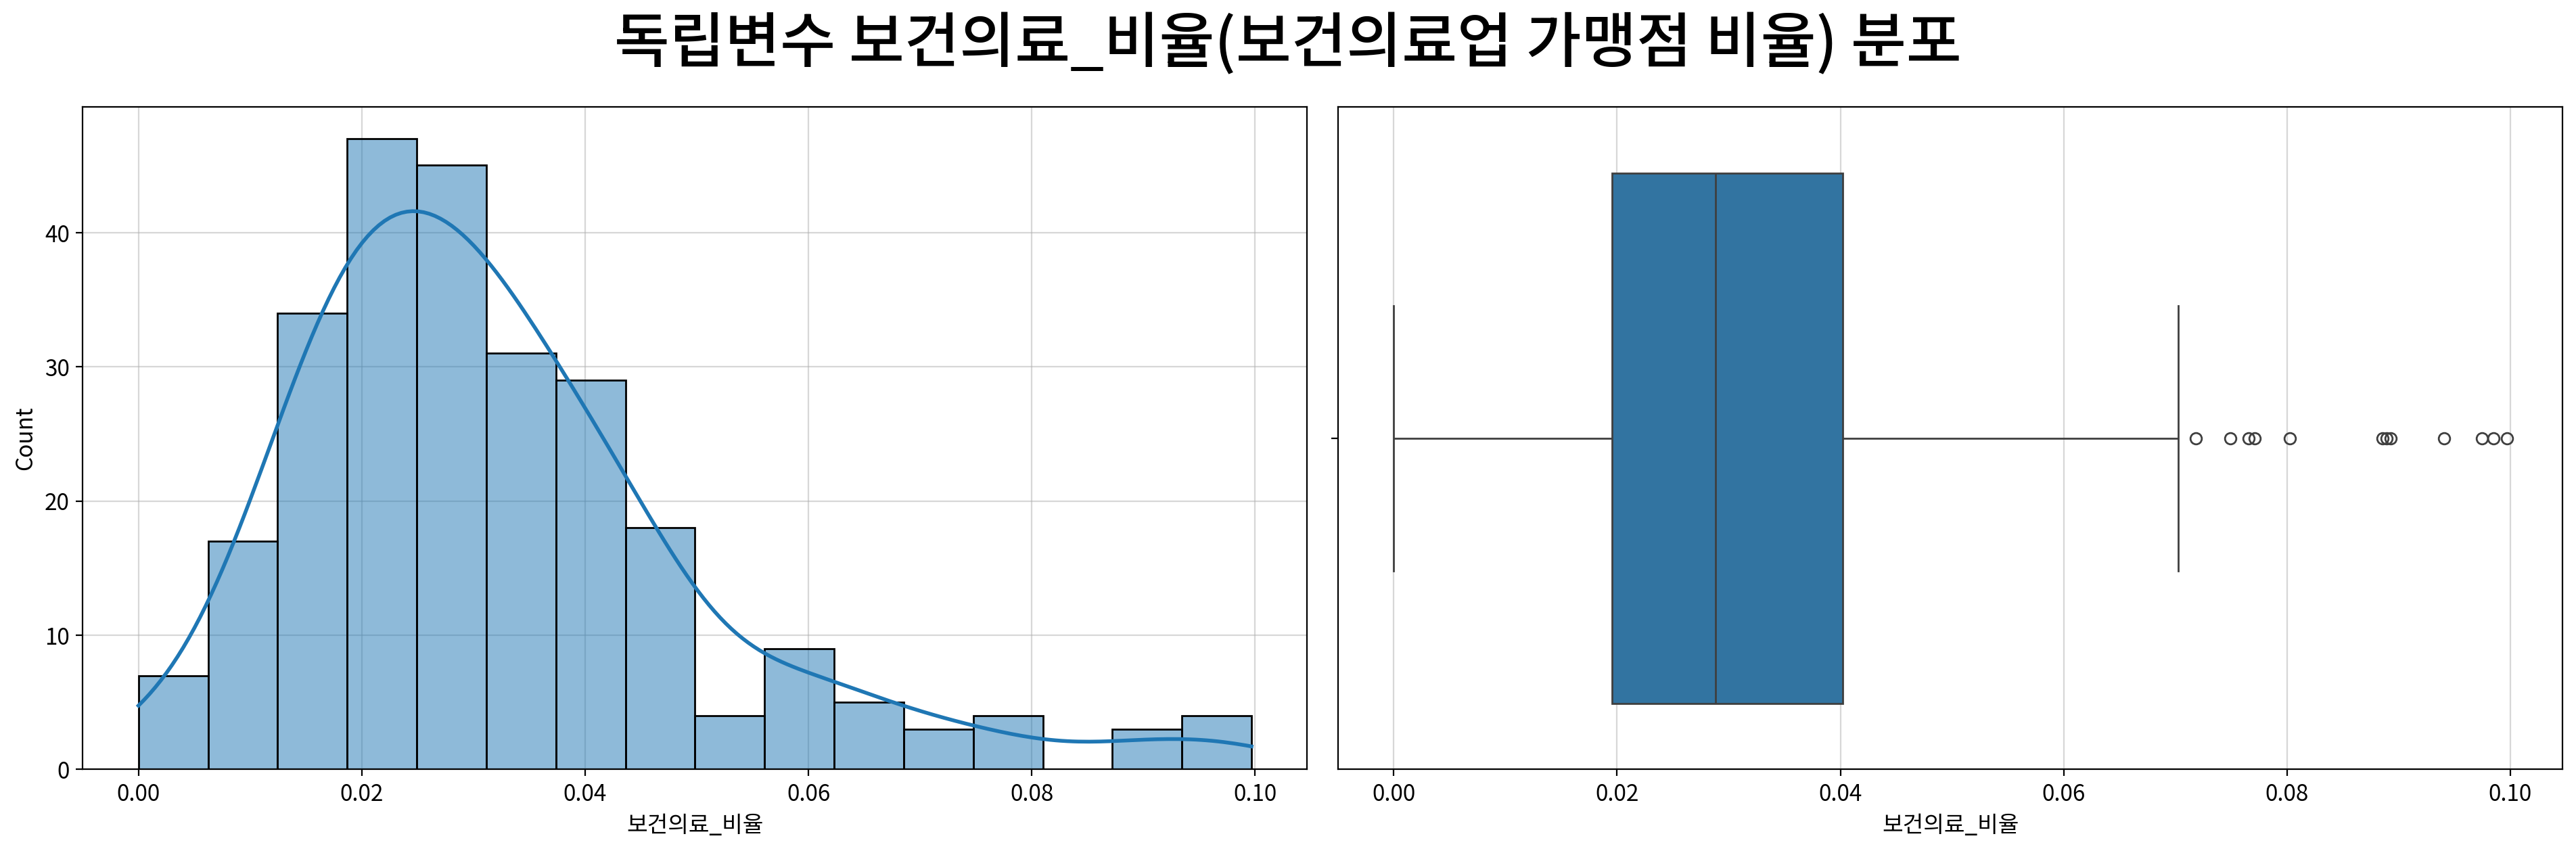

,보건의료_비율
count,260
mean,0.032215
std,0.018519
min,0.0
25%,0.019565
50%,0.028832
75%,0.040201
max,0.099684
rel_diff,0.117321
rdiff_flag,diff


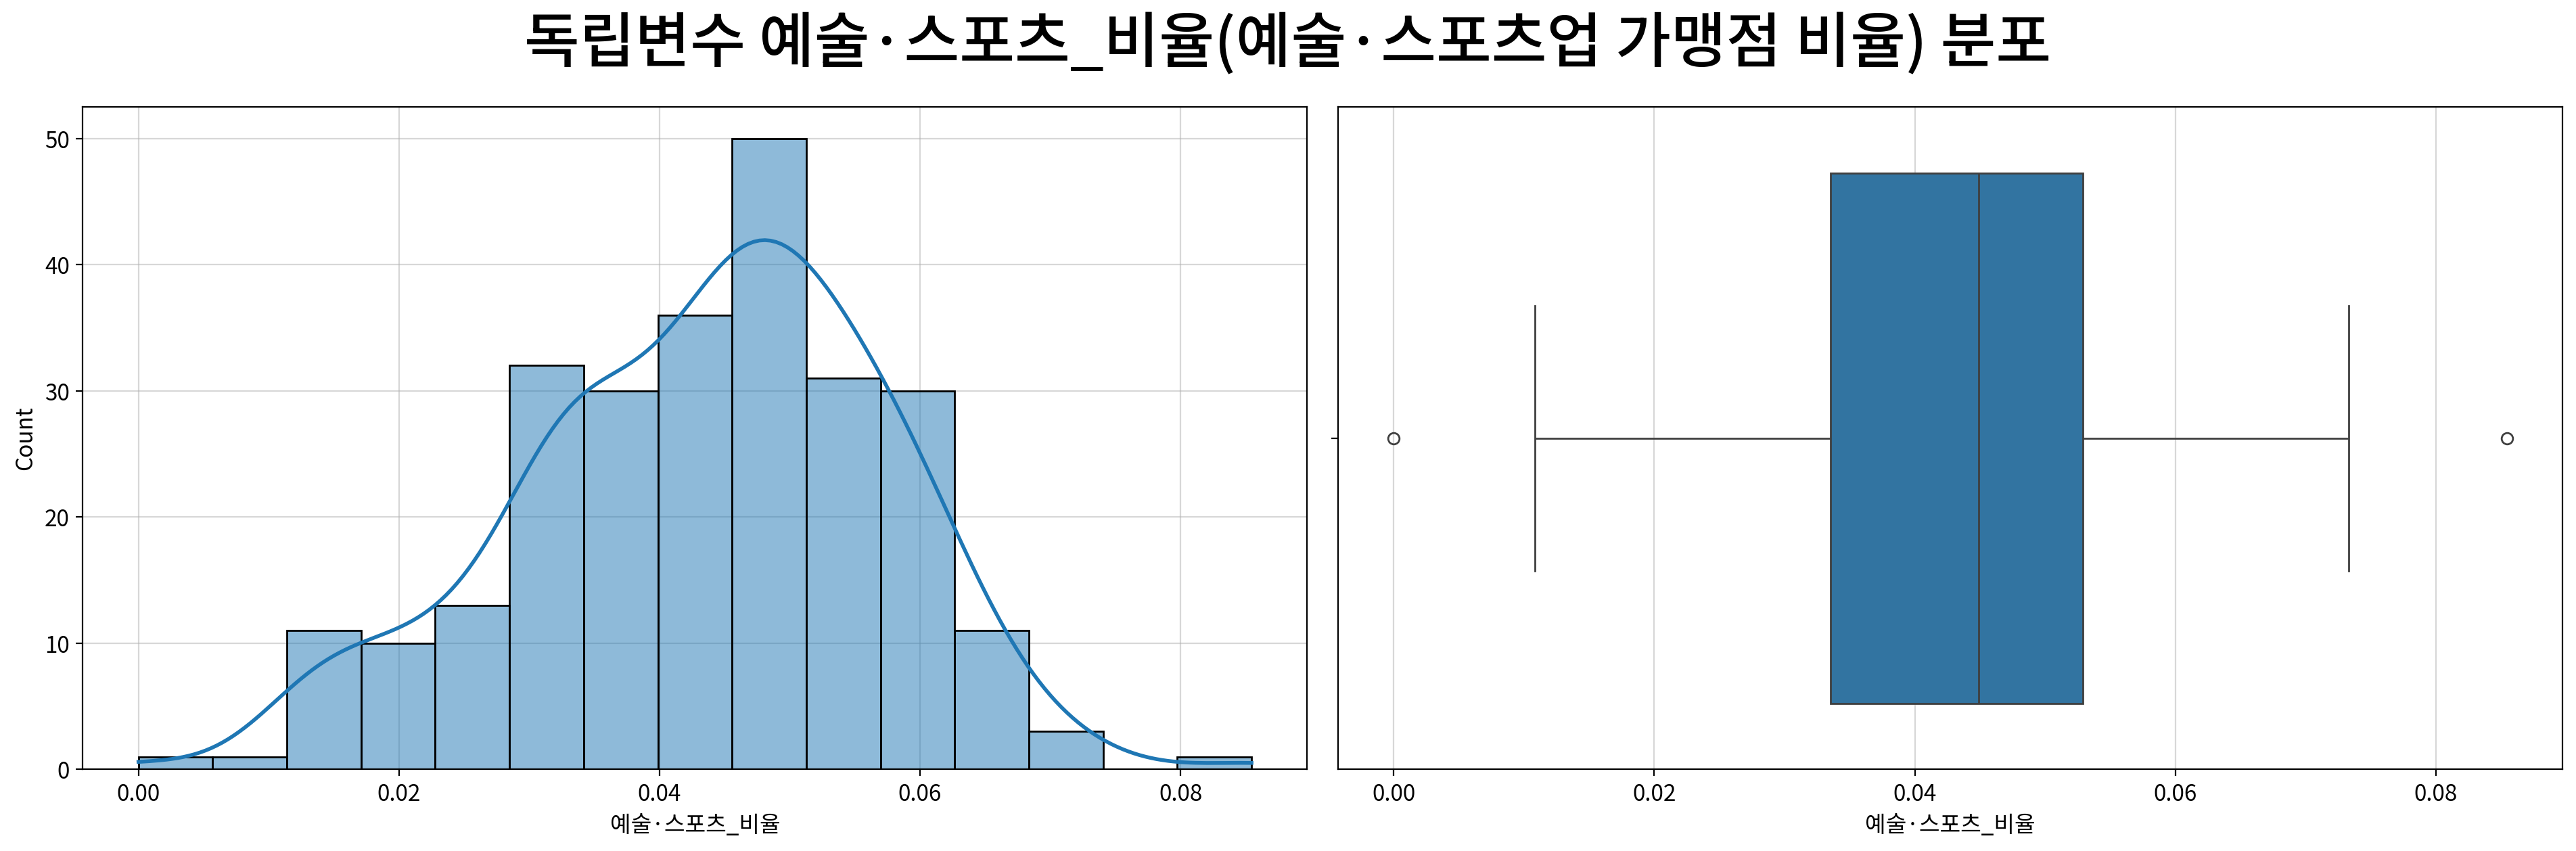

,예술·스포츠_비율
count,260
mean,0.043321
std,0.013946
min,0.0
25%,0.033553
50%,0.044885
75%,0.052922
max,0.085455
rel_diff,0.034834
rdiff_flag,similar


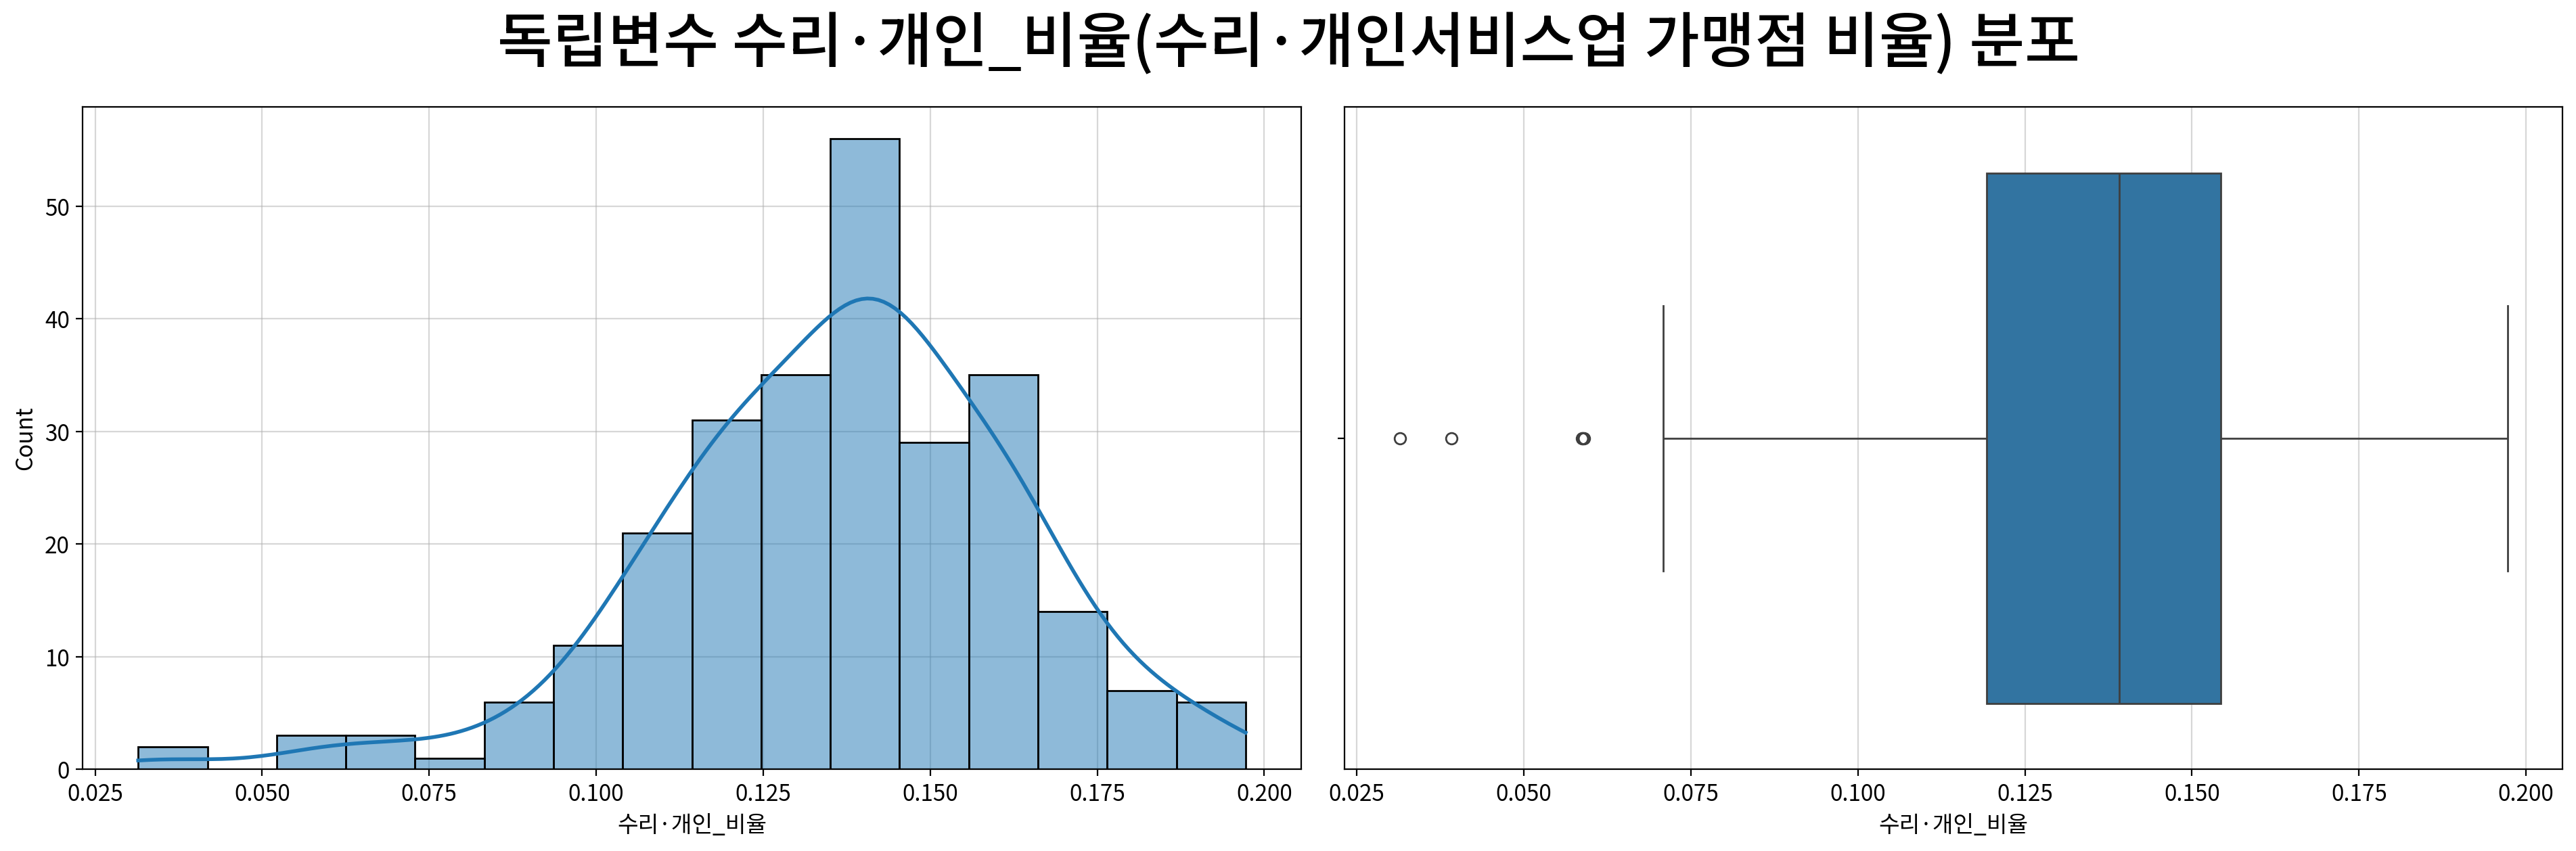

,수리·개인_비율
count,260
mean,0.136319
std,0.026992
min,0.031451
25%,0.119228
50%,0.139089
75%,0.154341
max,0.1972
rel_diff,0.019919
rdiff_flag,similar


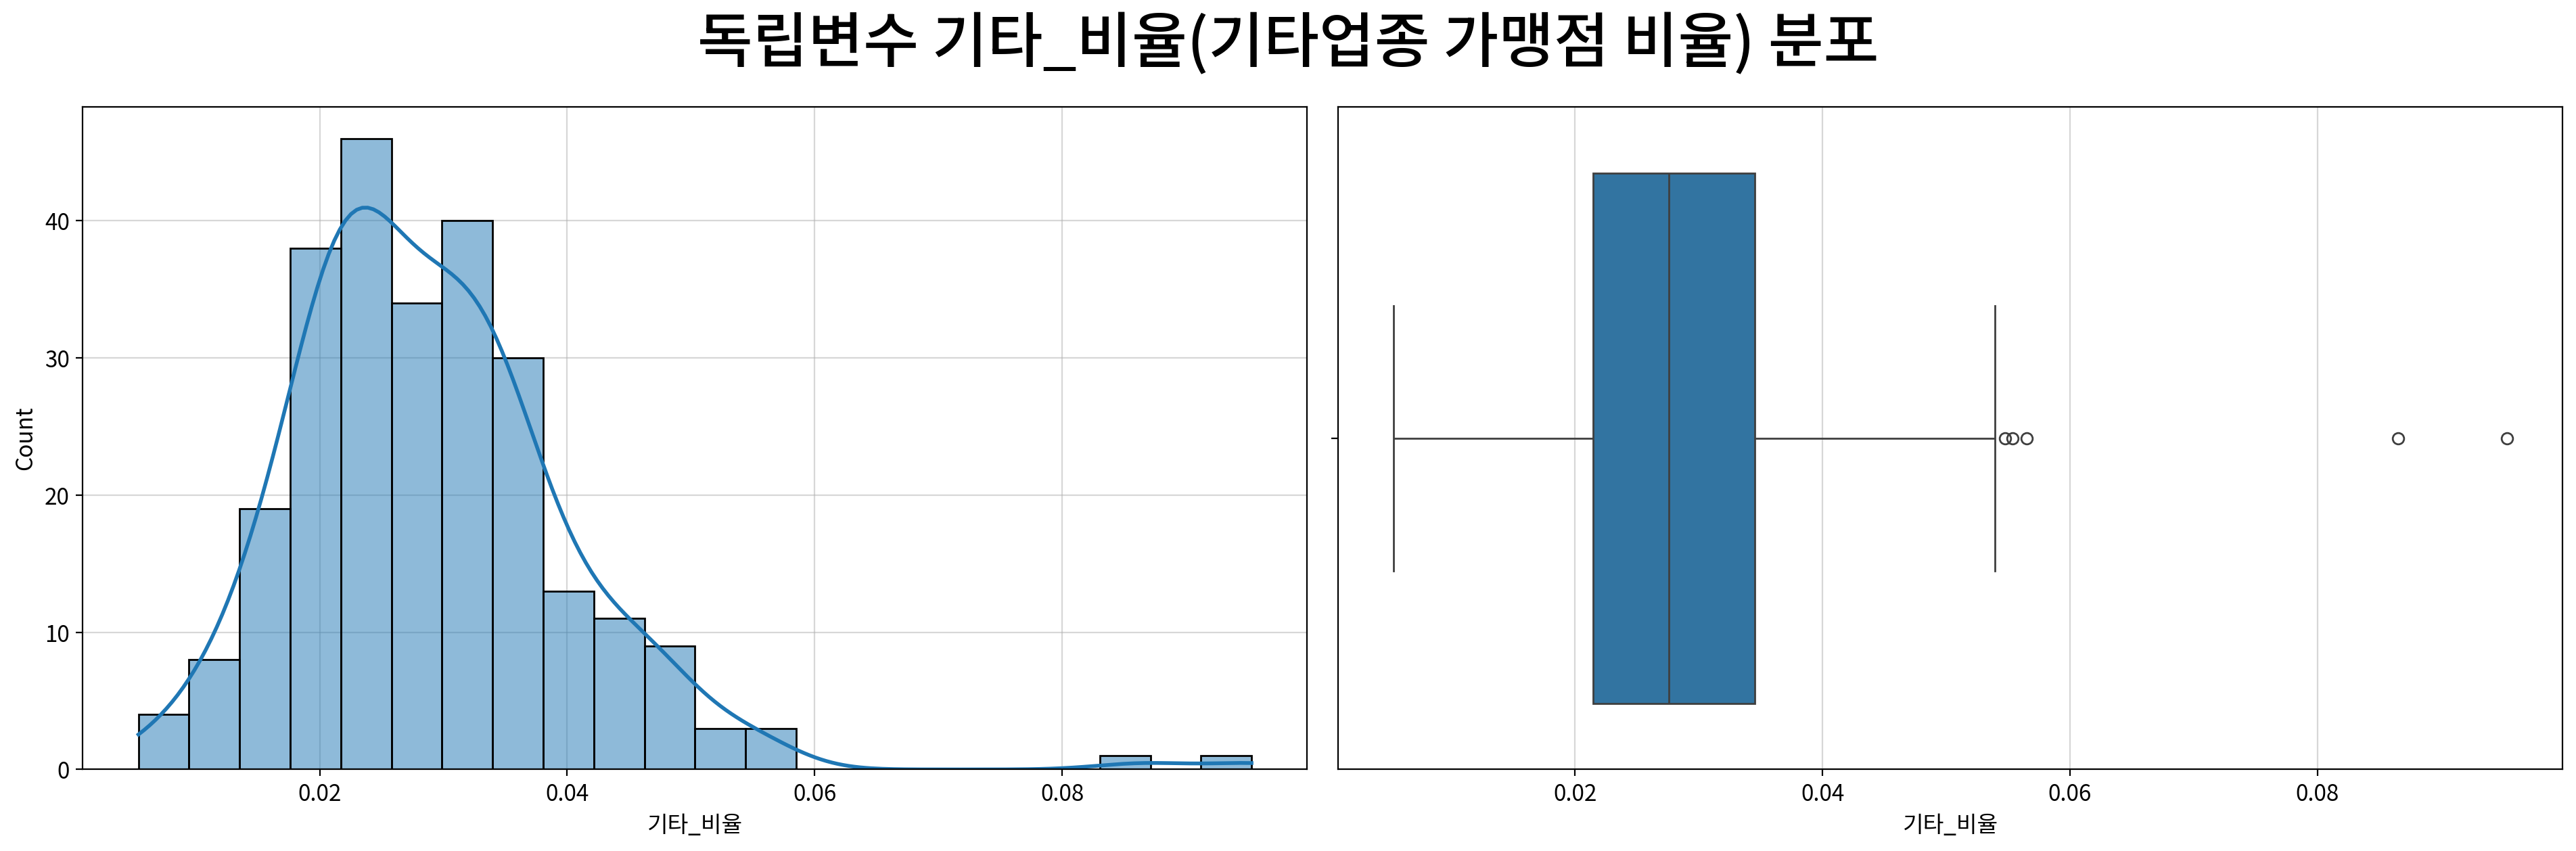

,기타_비율
count,260
mean,0.028915
std,0.011282
min,0.005357
25%,0.021473
50%,0.027595
75%,0.034528
max,0.095299
rel_diff,0.047831
rdiff_flag,similar


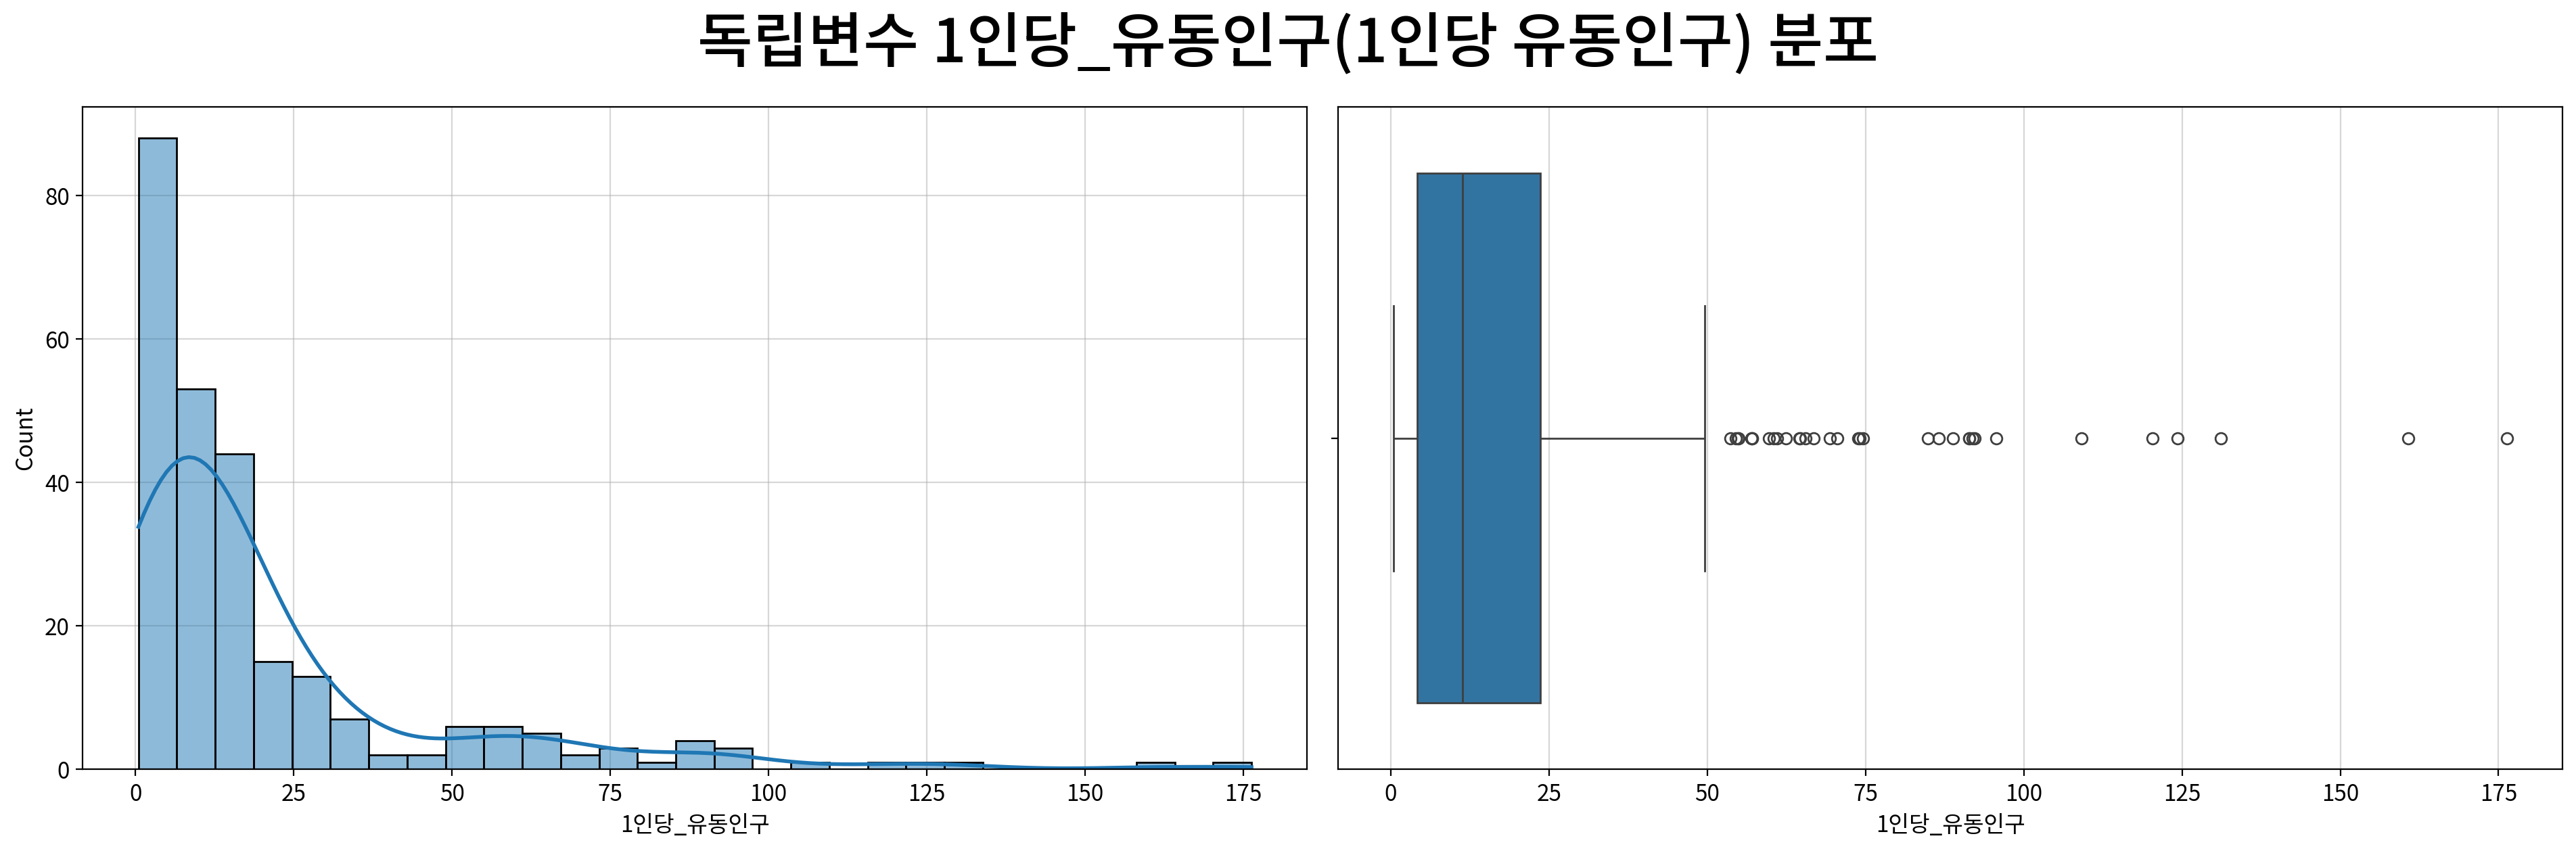

,1인당_유동인구
count,260
mean,21.068004
std,27.82589
min,0.470876
25%,4.129418
50%,11.369537
75%,23.593814
max,176.313867
rel_diff,0.853022
rdiff_flag,large_diff


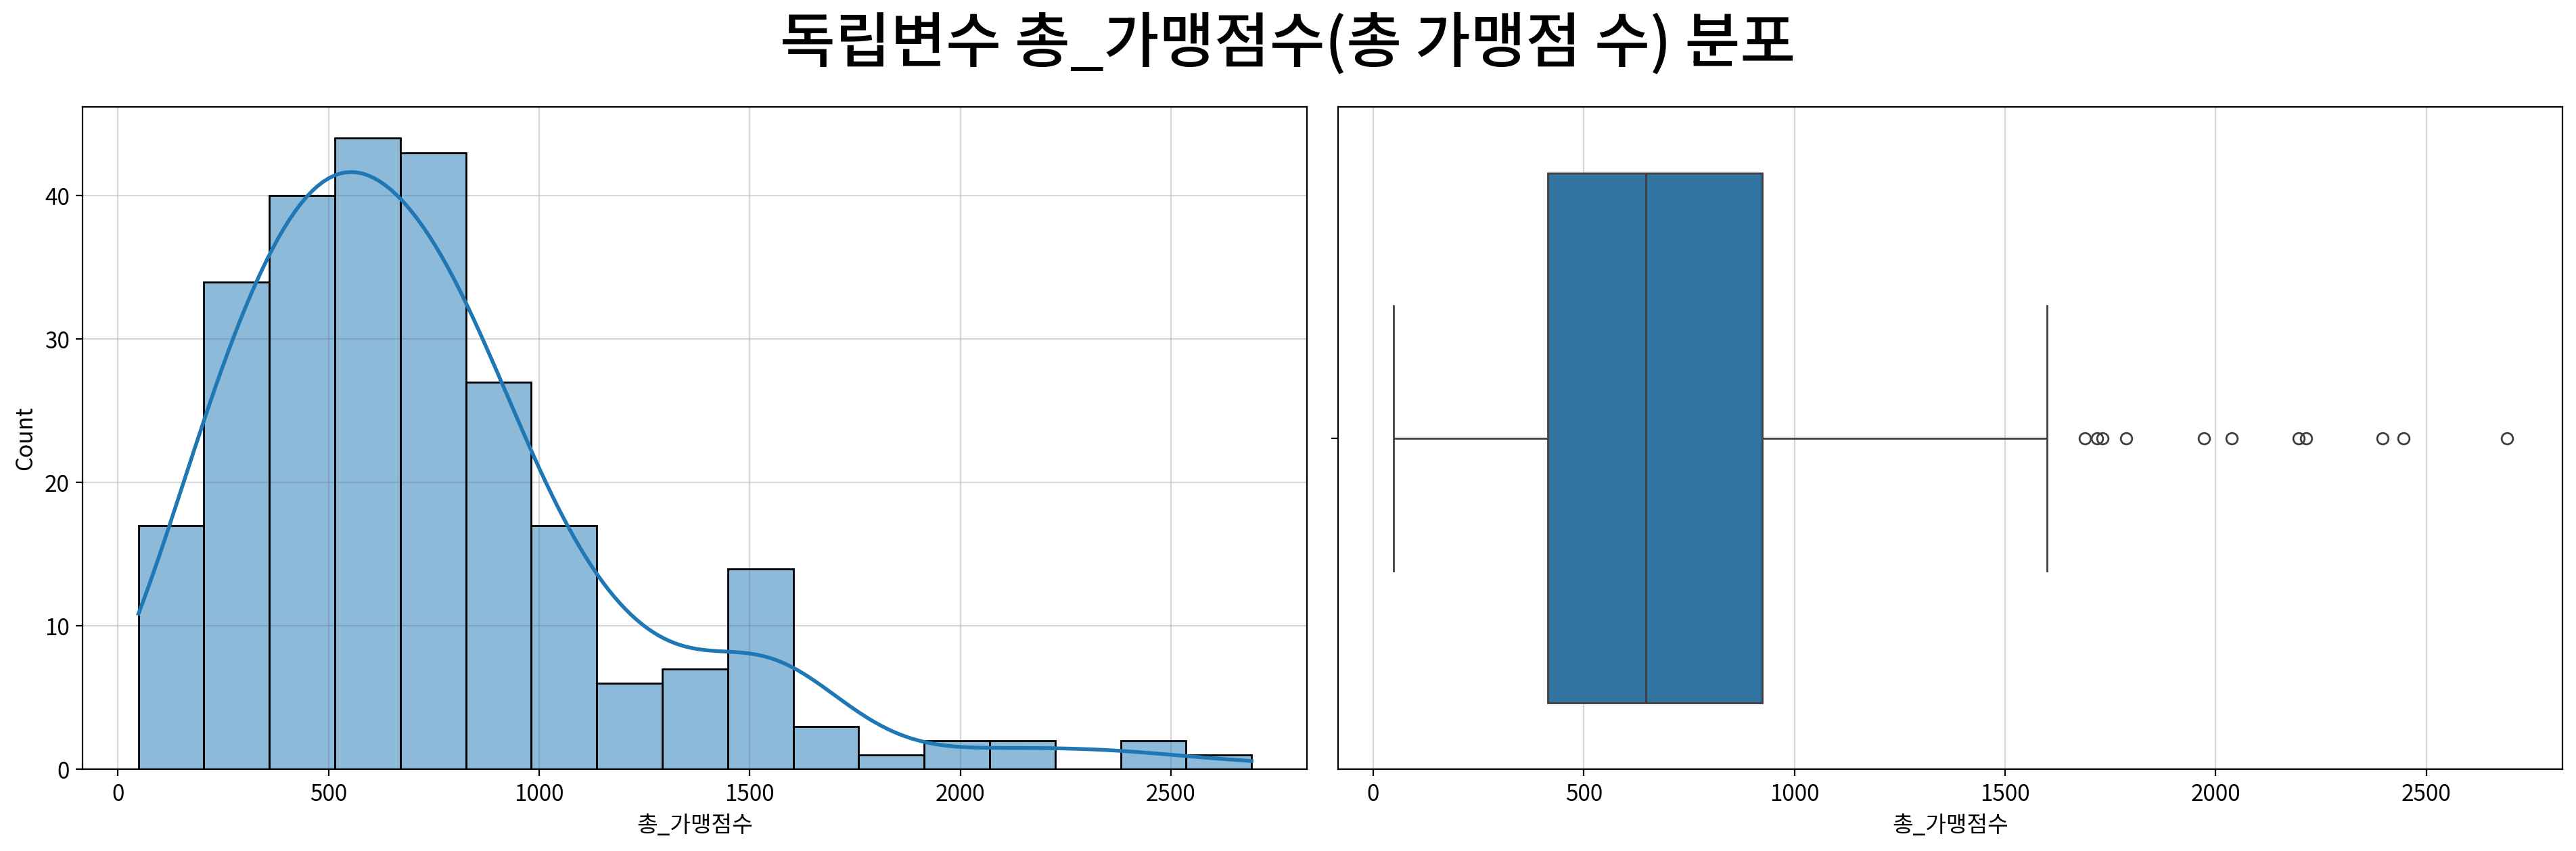

,총_가맹점수
count,260
mean,732.339744
std,458.936871
min,48.666667
25%,413.75
50%,647.833333
75%,923.583333
max,2691.333333
rel_diff,0.130445
rdiff_flag,diff


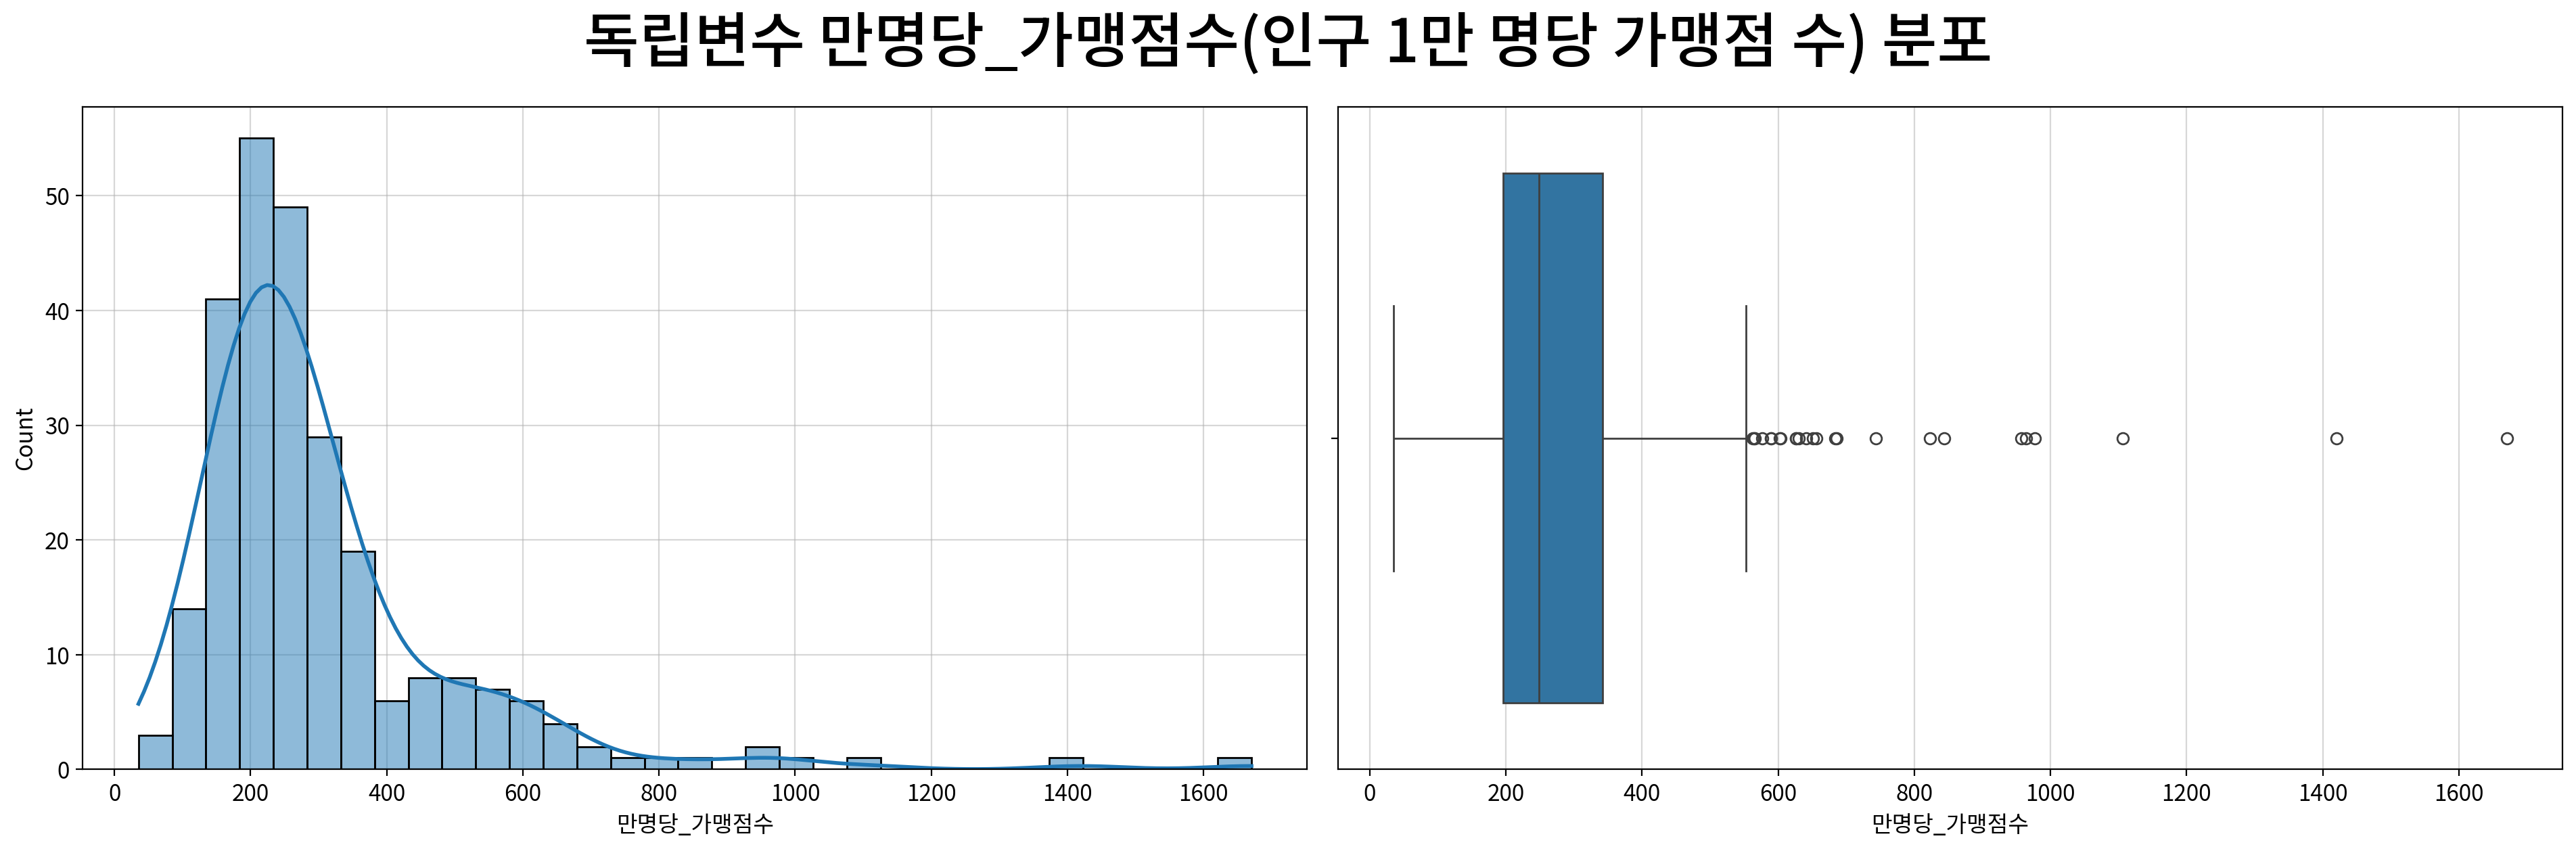

,만명당_가맹점수
count,260
mean,304.971812
std,200.230659
min,35.297246
25%,195.886758
50%,248.731477
75%,341.624296
max,1670.467248
rel_diff,0.226109
rdiff_flag,diff


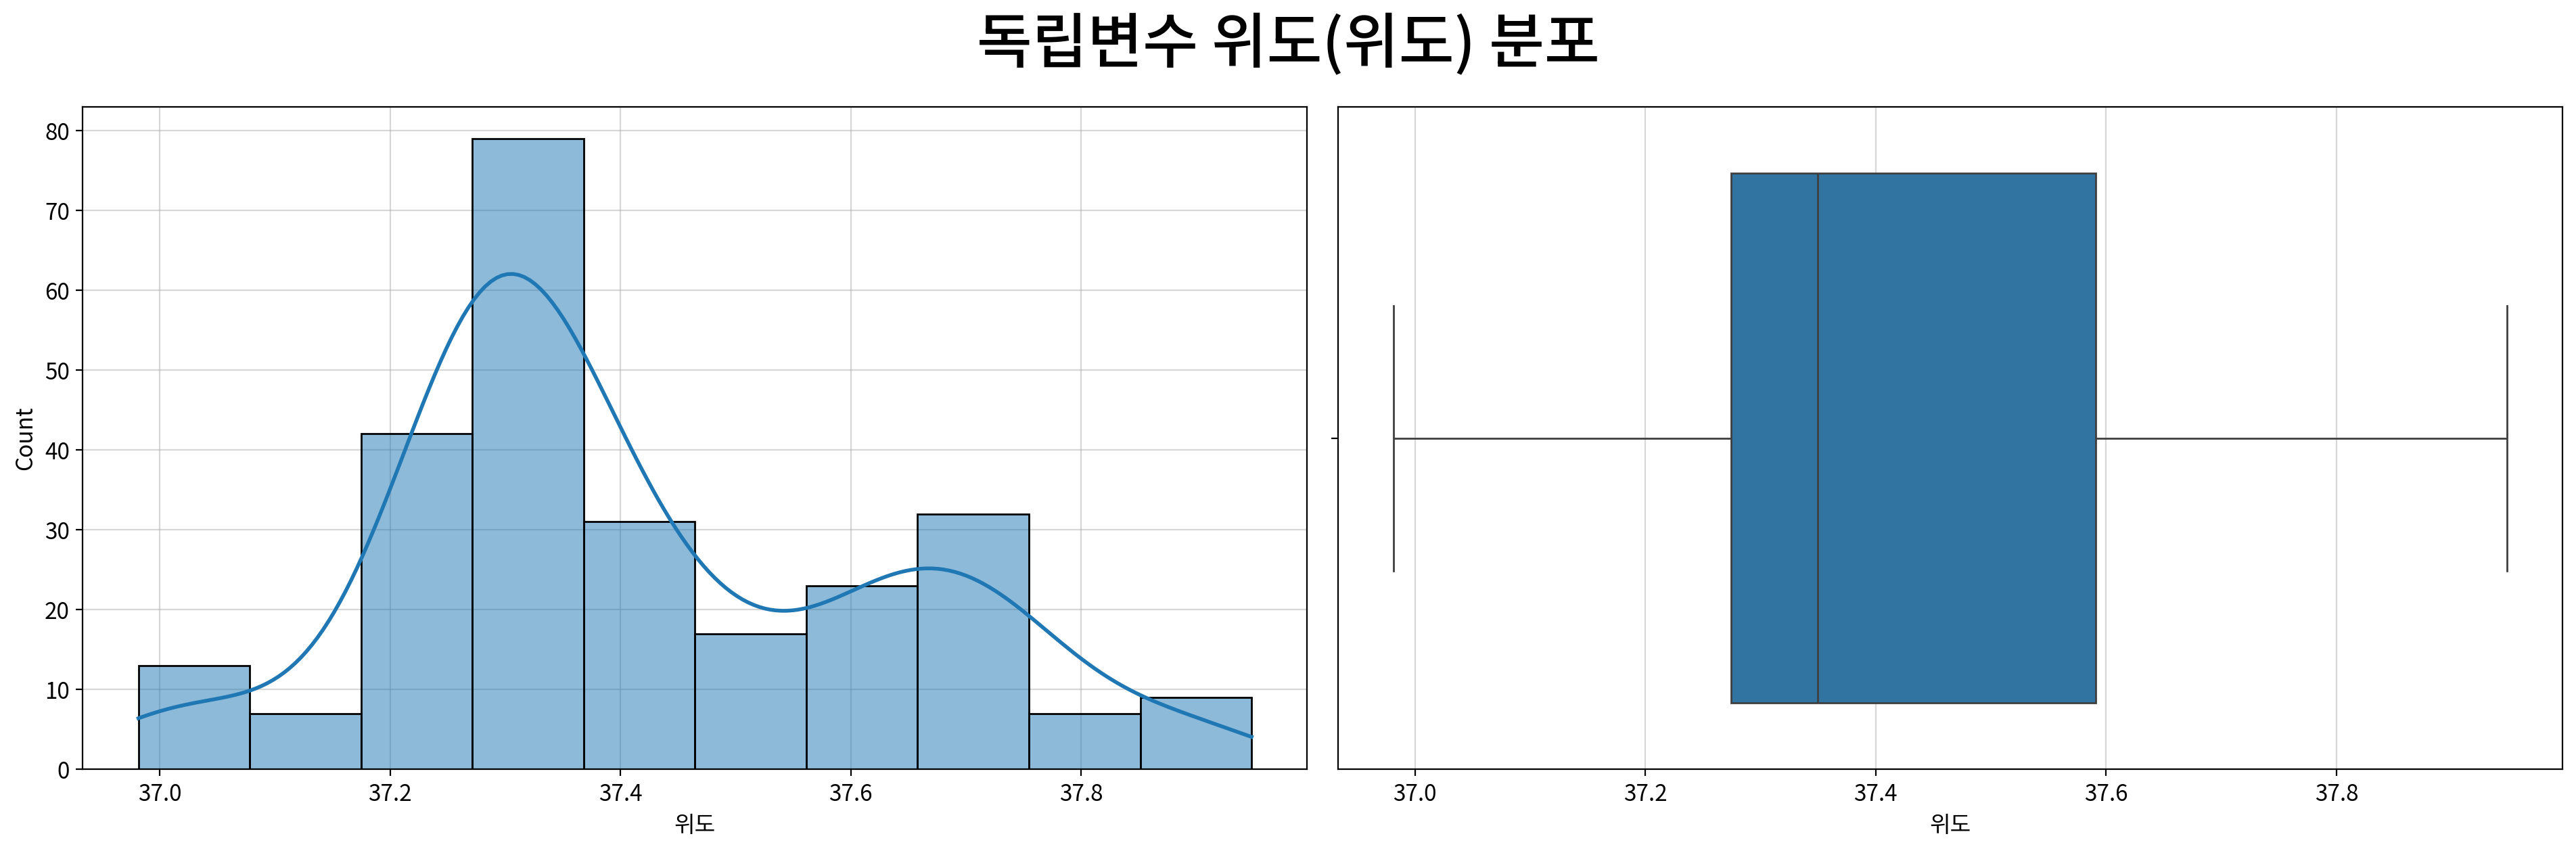

,위도
count,260
mean,37.413193
std,0.21244
min,36.981691
25%,37.274699
50%,37.349577
75%,37.590738
max,37.947779
rel_diff,0.001703
rdiff_flag,similar


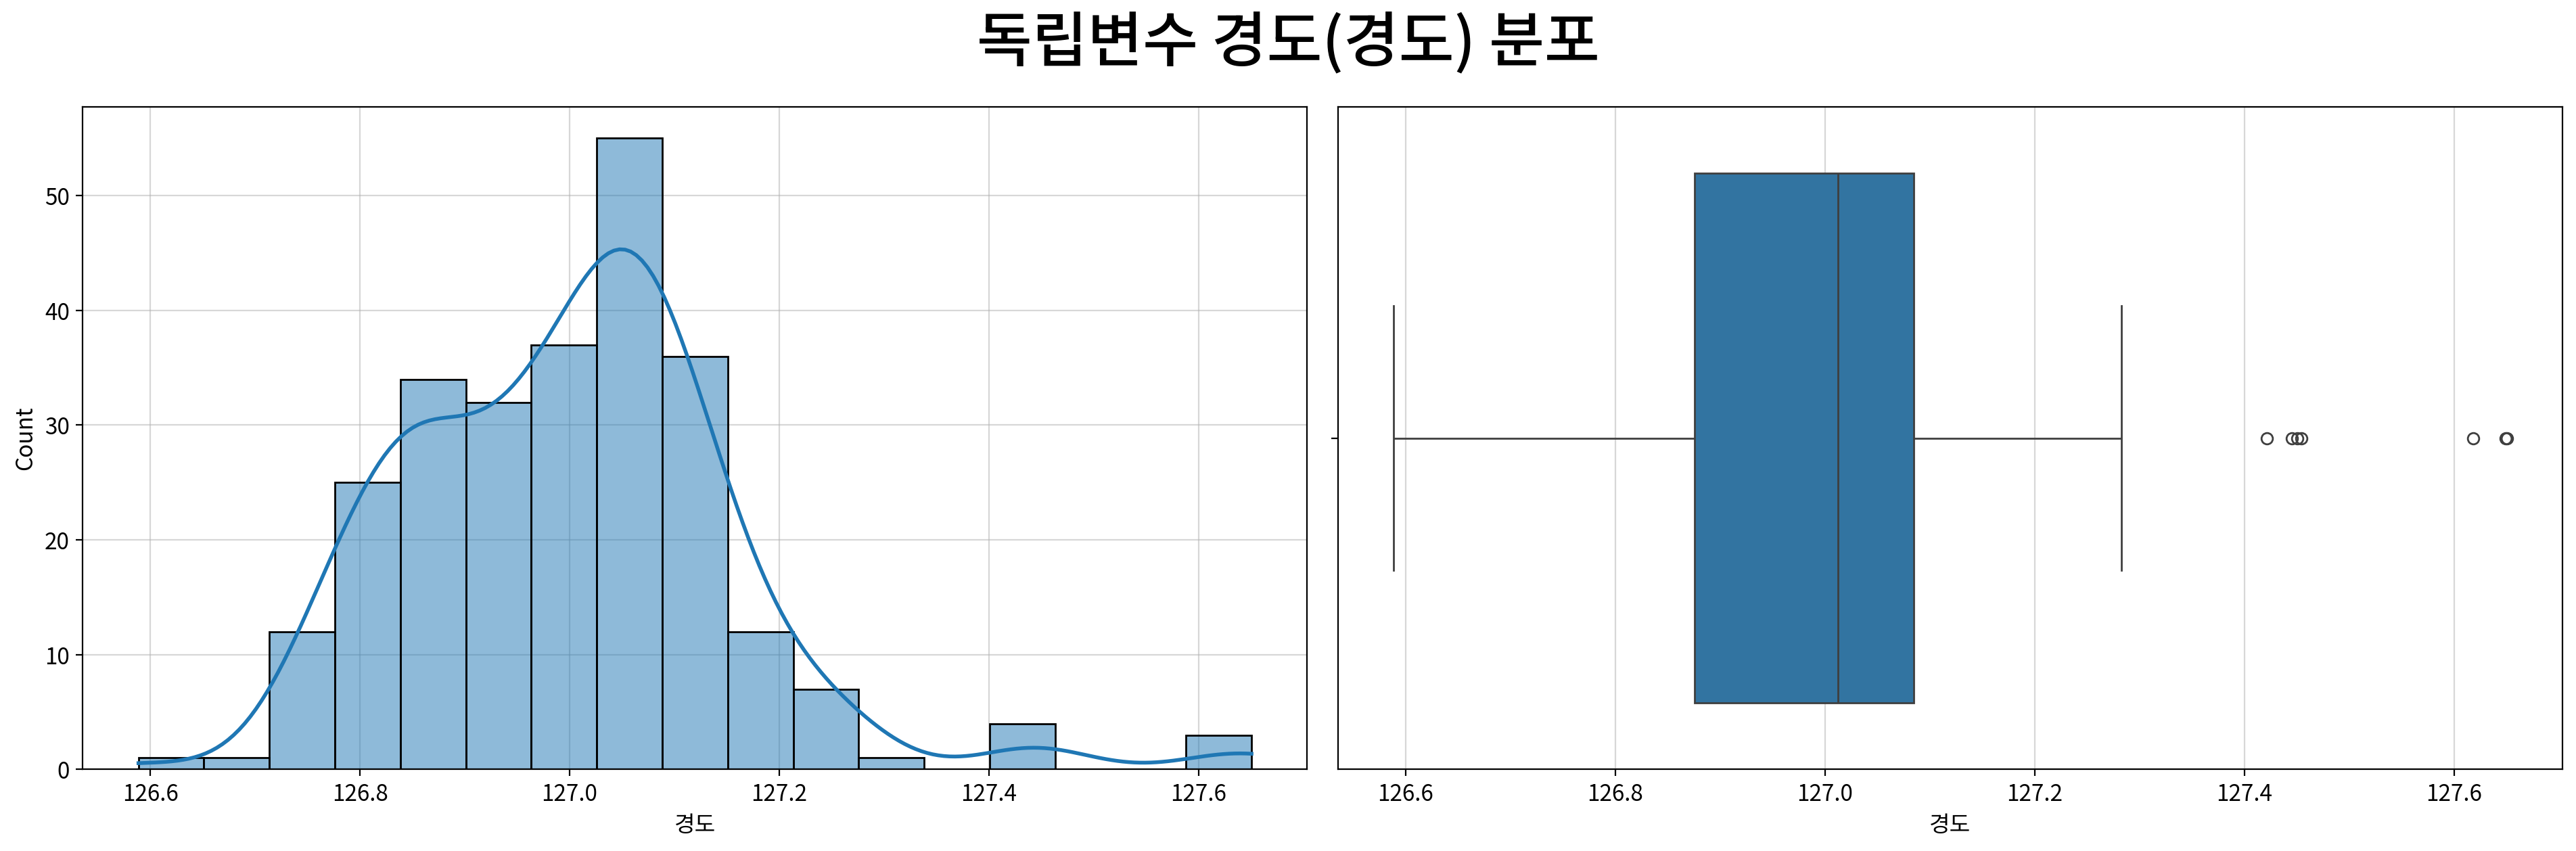

,경도
count,260
mean,127.001981
std,0.156258
min,126.58874
25%,126.875415
50%,127.012379
75%,127.084567
max,127.650435
rel_diff,0.000082
rdiff_flag,similar


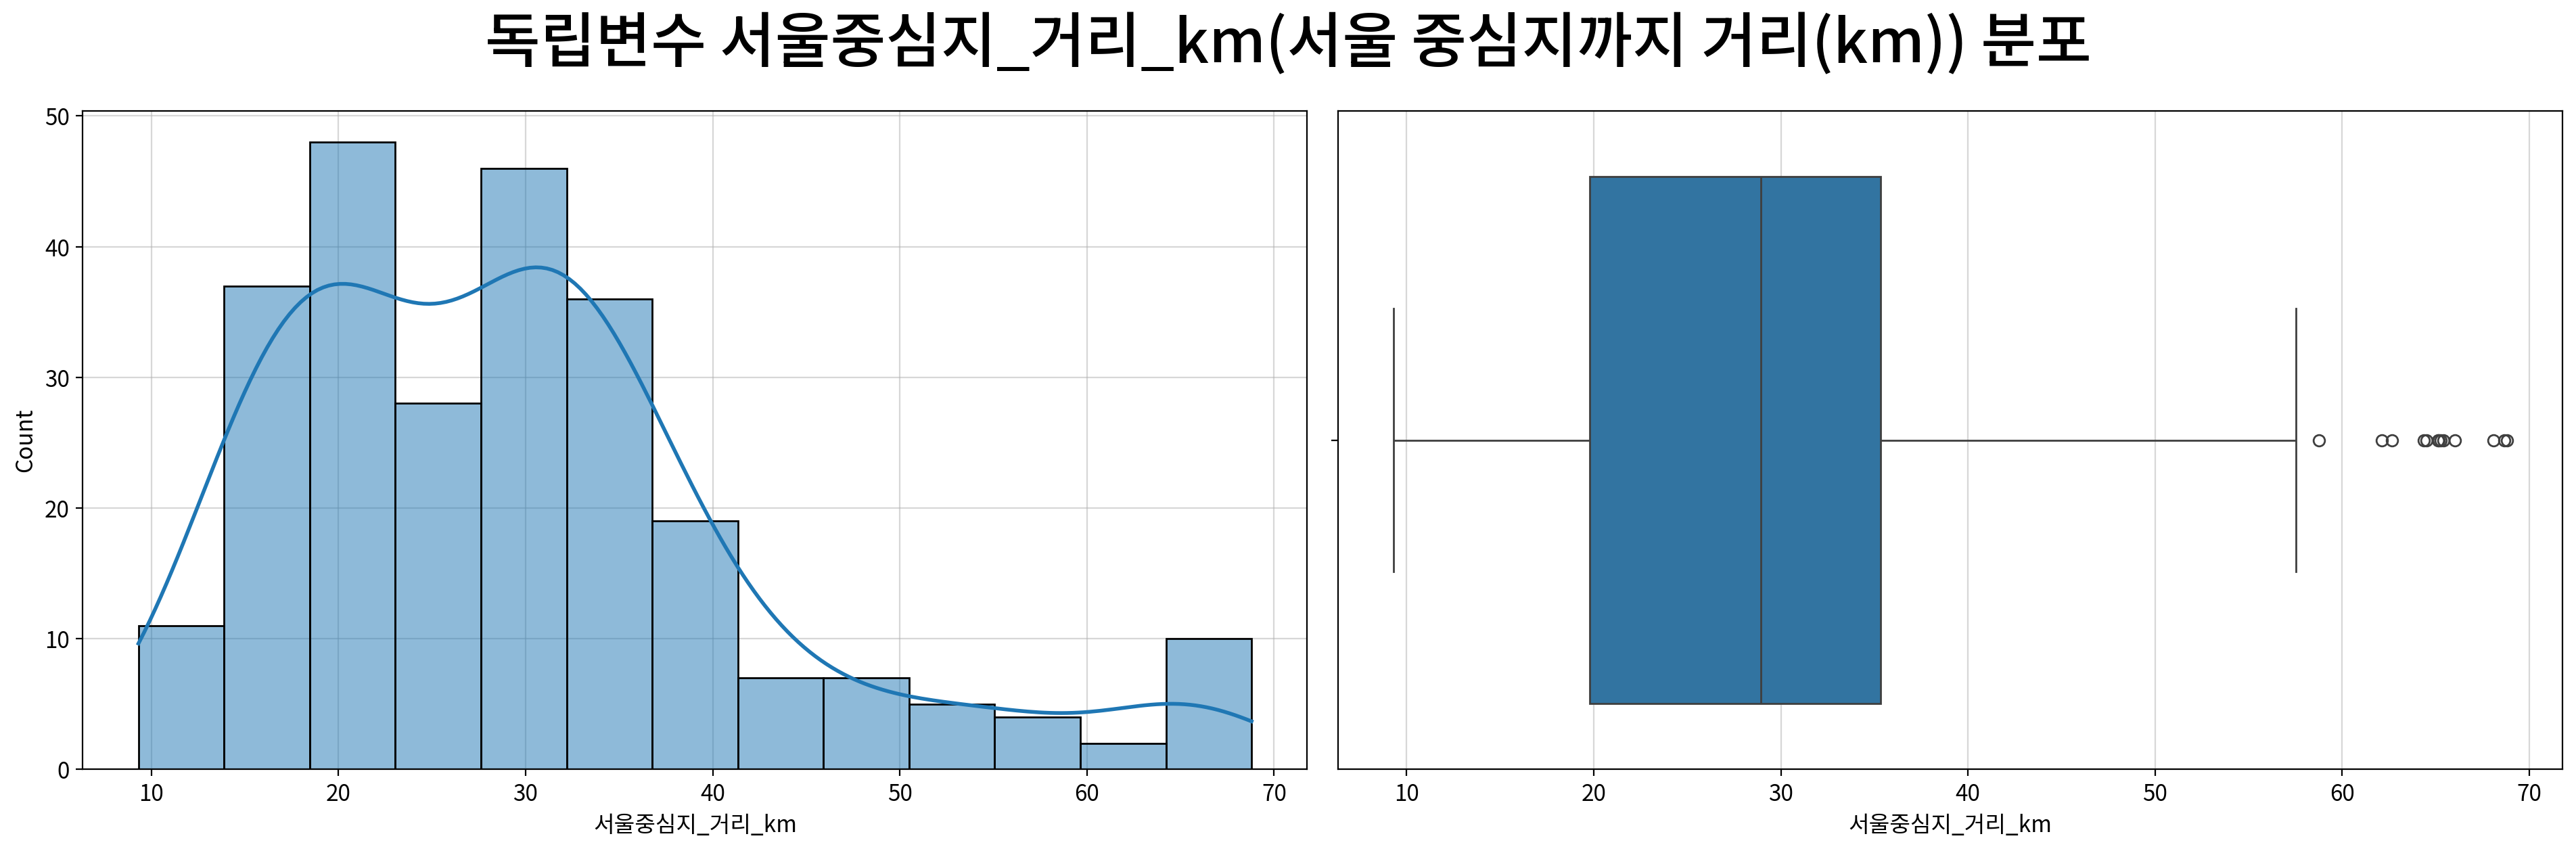

,서울중심지_거리_km
count,260
mean,29.604094
std,12.837253
min,9.30956
25%,19.778749
50%,28.935343
75%,35.326152
max,68.79466
rel_diff,0.023112
rdiff_flag,similar


In [54]:
# 2. 연속형 독립변수에 대한 단변량 분석

for f in continuous_cols:
    fig, ax = my_plot.init(rows=1, cols=2, width=960, height=640,
                           title=f"독립변수 {f}({column_means[f]}) 분포")

    my_plot.histplot(data=df2, x=f, kde=True, ax=ax[0])
    my_plot.boxplot(data=df2, x=f, ax=ax[1])
    my_plot.show()

    display(num_desc[num_desc.index == f].T)

In [56]:
corr_list = []

for f in continuous_cols:
    corr_list.append(my_stats.correlation(df2, x=f, y=target, plot=False))

# 11개 결과를 한 표로 합쳐 상관계수 내림차순 정렬
corr_result = concat(corr_list).sort_values("coef", ascending=False)
display(corr_result)

print("[ 상관 강도 판정별 변수 개수 ]")
print(corr_result['strength'].value_counts())

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
전체가맹점수,평균매출,Spearman,0.5312,0.0000,Moderate,True,False,False,True,True,True
총_가맹점수,평균매출,Spearman,0.5312,0.0000,Moderate,True,False,False,True,True,True
총인구수,평균매출,Spearman,0.4321,0.0000,Moderate,True,False,False,False,True,True
예술·스포츠_비율,평균매출,Spearman,0.2798,0.0000,Weak,True,True,False,True,True,True
행정동코드,평균매출,Spearman,0.2432,0.0001,Weak,True,False,False,True,True,True
경도,평균매출,Spearman,0.2225,0.0003,Weak,True,False,False,True,True,True
만명당_가맹점수,평균매출,Spearman,0.2219,0.0003,Weak,True,False,False,True,False,True
교육_비율,평균매출,Spearman,0.2175,0.0004,Weak,True,False,False,False,True,True
보건의료_비율,평균매출,Spearman,0.2147,0.0005,Weak,True,False,False,False,True,True


[ 상관 강도 판정별 변수 개수 ]
strength
Weak        17
Moderate     4
Name: count, dtype: int64
